<a href="https://colab.research.google.com/github/tejasmanojav/momentum_trading/blob/main/momentum_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Data Setup and Hyperparameters

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# --- Global Hyperparameters and Configuration ---
# Using 5 tickers for a diversified market view
TARGET_TICKERS = ['SPY', 'QQQ', 'DIA', 'IWM', 'VTI']
START_DATE_STR = '2004-01-01'
END_DATE_STR = '2024-12-31' # Set to a fixed full-year end date

# Strategy Parameters
MA_WINDOWS = {20: 'red', 50: 'green', 100: 'orange', 200: 'blue'}
EPSILON = 0.02
TRAILING_STOP_PCT = 0.05

RSI_WINDOW = 14
RSI_OVERSOLD = 30
RSI_OVERBOUGHT = 70

# Download data for all tickers into a dictionary
data_dict = {}
for ticker in TARGET_TICKERS:
    print(f"Downloading {ticker}...")
    df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    data_dict[ticker] = df

print(f"\n20-year data downloaded for: {', '.join(TARGET_TICKERS)}")

/tmp/ipykernel_5180/3864751742.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5180/3864751742.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR)


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5180/3864751742.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR)


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5180/3864751742.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR)


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5180/3864751742.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR)


[*********************100%***********************]  1 of 1 completed


20-year data downloaded for: SPY, QQQ, DIA, IWM, VTI


In [2]:
# Data Inspection for multiple tickers
for ticker, df in data_dict.items():
    print(f"--- {ticker} Preview ---")
    display(df.head())
    print(f"{ticker} Shape: {df.shape}\n")

--- SPY Preview ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,73.644173,74.279778,73.313128,73.981834,38072300
2004-01-05,74.445305,74.498268,73.882525,73.948738,27959800
2004-01-06,74.518120,74.637296,74.153969,74.259906,20472800
2004-01-07,74.769707,74.855776,74.081134,74.412178,30170400
2004-01-08,75.067635,75.087501,74.663760,74.981565,36438400


SPY Shape: (5284, 5)

--- QQQ Preview ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,30.683876,31.046749,30.565732,30.937043,55234100
2004-01-05,31.299917,31.358989,30.852656,30.869534,69717900
2004-01-06,31.510874,31.578383,31.181757,31.291464,60033000
2004-01-07,31.797810,31.797810,31.283036,31.460252,71830000
2004-01-08,32.050976,32.067854,31.730296,31.941269,76800900


QQQ Shape: (5284, 5)

--- DIA Preview ---


...

DIA Shape: (5284, 5)

--- IWM Preview ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,41.701378,41.939693,41.392315,41.396037,11182200
2004-01-05,42.189171,42.282263,41.820526,41.984368,8686000
2004-01-06,42.133320,42.498238,42.077464,42.215241,6196800
2004-01-07,42.580151,42.654626,42.062561,42.196613,5919600
2004-01-08,42.904099,43.094006,42.602482,42.926440,6201200


IWM Shape: (5284, 5)

--- VTI Preview ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,35.719009,36.064363,35.628481,36.007364,390200
2004-01-05,36.118031,36.164972,35.916854,36.007382,368200
2004-01-06,36.242092,36.282329,36.047623,36.138151,244000
2004-01-07,36.346031,36.346031,36.044265,36.228678,209800
2004-01-08,36.480148,36.503619,36.329264,36.496912,250400


VTI Shape: (5284, 5)



# Section 2: Strategy Definition and Metrics

### Helper Functions and Strategy Definitions

In [3]:
import pandas as pd
import numpy as np

def calculate_max_drawdown(returns_series):
    if returns_series.empty: return 0
    cum_rets = (1 + returns_series).cumprod()
    peak = cum_rets.expanding(min_periods=1).max()
    return ((cum_rets / peak) - 1).min()

def calculate_trade_returns(trade_events_df):
    trades = []
    df = trade_events_df.reset_index()
    if len(df) % 2 != 0:
        df = df.iloc[:-1]

    for i in range(0, len(df), 2):
        entry = df.iloc[i]
        exit = df.iloc[i+1]
        if entry['Trade'] == 'BUY':
            ret = (exit['Close'] / entry['Close']) - 1
            trades.append({'ExitDate': exit['Date'], 'Return_Pct': ret})
    return pd.DataFrame(trades)

def calculate_atr(df, window=14):
    high, low, close_prev = df['High'], df['Low'], df['Close'].shift(1)
    tr = pd.concat([high - low, (high - close_prev).abs(), (low - close_prev).abs()], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(window=window).mean()
    return df

def calculate_rsi(df, window=14):
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = np.where(loss == 0, np.inf, gain / loss)
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

def add_rsi_signals(df, oversold=30, overbought=70):
    temp = calculate_rsi(df.copy())
    signals = []
    last_signal = None
    for i in range(len(temp)):
        rsi = temp['RSI'].iloc[i]
        if rsi < oversold and last_signal != 'BUY':
            signals.append({'Date': temp.index[i], 'Close': temp['Close'].iloc[i], 'Trade': 'BUY'})
            last_signal = 'BUY'
        elif rsi > overbought and last_signal == 'BUY':
            signals.append({'Date': temp.index[i], 'Close': temp['Close'].iloc[i], 'Trade': 'SELL'})
            last_signal = None
    return pd.DataFrame(signals).set_index('Date') if signals else pd.DataFrame()

def trade_ma_with_fixed_trailing_stop(df, window_length, epsilon=0.02, trailing_stop_pct=0.05):
    temp = df.copy()
    temp['MA'] = temp['Close'].rolling(window=window_length).mean()
    signals, current_pos, stop_loss = [], None, 0
    valid_df = temp[temp['MA'].notna()].copy()

    for i in range(len(valid_df)):
        price = valid_df['Close'].iloc[i]
        m = valid_df['MA'].iloc[i]
        if current_pos is None:
            if price > m * (1 + epsilon):
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'BUY'})
                current_pos = 'LONG'
                stop_loss = price * (1 - trailing_stop_pct)
        elif current_pos == 'LONG':
            stop_loss = max(stop_loss, price * (1 - trailing_stop_pct))
            if price < m * (1 - epsilon) or price < stop_loss:
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'SELL'})
                current_pos = None
    return pd.DataFrame(signals).set_index('Date') if signals else pd.DataFrame()

def trade_ma_with_atr_stop(df, window_length, epsilon=0.02, atr_multiplier=2.0):
    temp = df.copy()
    temp['MA'] = temp['Close'].rolling(window=window_length).mean()
    temp = calculate_atr(temp)
    signals, current_pos, stop_loss = [], None, 0
    valid_df = temp[temp['MA'].notna() & temp['ATR'].notna()].copy()

    for i in range(len(valid_df)):
        price = valid_df['Close'].iloc[i]
        m = valid_df['MA'].iloc[i]
        atr = valid_df['ATR'].iloc[i]
        if current_pos is None:
            if price > m * (1 + epsilon):
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'BUY'})
                current_pos = 'LONG'
                stop_loss = price - (atr * atr_multiplier)
        elif current_pos == 'LONG':
            stop_loss = max(stop_loss, price - (atr * atr_multiplier))
            if price < m * (1 - epsilon) or price < stop_loss:
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'SELL'})
                current_pos = None
    return pd.DataFrame(signals).set_index('Date') if signals else pd.DataFrame()

In [4]:
def trade_confluence_persistent_state(df, window_ma=200, rsi_os=30, rsi_ob=70, epsilon=0.02):
    """
    Persistent Confluence Strategy:
    Unlike standard confluence which triggers on a 'touch' of a level, this logic treats
    indicators as 'States'.

    - BUY: Occurs only when the price is currently in an 'Uptrend State' (Price > MA + Epsilon)
           AND the RSI is currently in an 'Oversold State' (RSI < 30).
    - SELL: Occurs when the price enters a 'Downtrend State' (Price < MA - Epsilon)
            AND the RSI is in an 'Overbought State' (RSI > 70).

    This ensures we only enter high-probability setups where a long-term trend
    and a short-term exhaustion signal coexist.
    """
    # 1. Calculate indicators
    ma_col = f'MA_{window_ma}'
    if ma_col not in df.columns:
        df[ma_col] = df['Close'].rolling(window=window_ma).mean()
    if 'RSI' not in df.columns:
        df = calculate_rsi(df)

    result_df = df.copy()
    result_df['Trade'] = None
    last_signal = None

    # 2. Define States (Booleans)
    result_df['In_Uptrend'] = result_df['Close'] > (result_df[ma_col] * (1 + epsilon))
    result_df['In_Downtrend'] = result_df['Close'] < (result_df[ma_col] * (1 - epsilon))
    result_df['Is_Oversold'] = result_df['RSI'] < rsi_os
    result_df['Is_Overbought'] = result_df['RSI'] > rsi_ob

    # 3. Iterate and Trigger on Confluence of States
    for i in range(1, len(result_df)):
        if result_df['In_Uptrend'].iloc[i] and result_df['Is_Oversold'].iloc[i]:
            if last_signal != 'BUY':
                result_df.at[result_df.index[i], 'Trade'] = 'BUY'
                last_signal = 'BUY'
        elif result_df['In_Downtrend'].iloc[i] and result_df['Is_Overbought'].iloc[i]:
            if last_signal != 'SELL':
                result_df.at[result_df.index[i], 'Trade'] = 'SELL'
                last_signal = 'SELL'

    return result_df[result_df['Trade'].notna()][['Close', 'Trade']]

In [5]:
# Re-running the consolidated backtest to evaluate ATR-based stop-loss performance
all_ticker_metrics = []

for ticker, ticker_data in data_dict.items():
    start_idx = 200
    eval_data = ticker_data.iloc[start_idx:].copy()

    # 1. Buy & Hold
    bh_total_ret = (eval_data['Close'].iloc[-1] / eval_data['Close'].iloc[0]) - 1
    all_ticker_metrics.append({
        'Ticker': ticker, 'Strategy': 'Buy & Hold', 'Total Return': bh_total_ret,
        'Max Drawdown': calculate_max_drawdown(eval_data['Close'].pct_change().dropna()),
        'Win Rate (%)': 100.0, 'Total Trades': 1
    })

    # 2. MA Strategies (Using ATR-based stops)
    for window in MA_WINDOWS.keys():
        # Note: trade_moving_average removed/replaced by trade_ma_with_fixed_trailing_stop in later logic
        trade_df = trade_ma_with_fixed_trailing_stop(ticker_data, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        if not trade_df.empty:
            rets_df = calculate_trade_returns(trade_df)
            if not rets_df.empty:
                all_ticker_metrics.append({
                    'Ticker': ticker, 'Strategy': f'{window}-Day MA',
                    'Total Return': (1 + rets_df['Return_Pct']).prod() - 1,
                    'Max Drawdown': calculate_max_drawdown(rets_df['Return_Pct']),
                    'Win Rate (%)': (rets_df['Return_Pct'] > 0).mean() * 100,
                    'Total Trades': len(rets_df)
                })

master_comparison_df = pd.DataFrame(all_ticker_metrics)
global_summary = master_comparison_df.groupby('Strategy').agg({
    'Total Return': 'mean', 'Max Drawdown': 'mean', 'Win Rate (%)': 'mean', 'Total Trades': 'sum'
}).reset_index()

display(global_summary.sort_values(by='Total Return', ascending=False))

,Strategy,Total Return,Max Drawdown,Win Rate (%),Total Trades
4,Buy & Hold,7.909880,-0.549111,100.000000,5
2,200-Day MA,3.300324,-0.193946,52.922549,302
1,20-Day MA,2.135633,-0.285552,48.566511,421
3,50-Day MA,2.056533,-0.177103,50.414814,312
0,100-Day MA,1.943410,-0.184730,48.616084,301


In [6]:
comparison_results = []

for ticker, df in data_dict.items():
    for window in MA_WINDOWS.keys():
        # 1. Backtest Fixed Trailing Stop (%)
        trades_fixed = trade_ma_with_fixed_trailing_stop(df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        if not trades_fixed.empty:
            rets_fixed = calculate_trade_returns(trades_fixed)
            comparison_results.append({
                'Ticker': ticker,
                'MA_Window': window,
                'Stop_Type': 'Fixed %',
                'Total Return': (1 + rets_fixed['Return_Pct']).prod() - 1,
                'Max Drawdown': calculate_max_drawdown(rets_fixed['Return_Pct']),
                'Trades': len(rets_fixed)
            })

        # 2. Backtest ATR Trailing Stop
        trades_atr = trade_ma_with_atr_stop(df, window, epsilon=EPSILON, atr_multiplier=2.0)
        if not trades_atr.empty:
            rets_atr = calculate_trade_returns(trades_atr)
            comparison_results.append({
                'Ticker': ticker,
                'MA_Window': window,
                'Stop_Type': 'ATR-Based',
                'Total Return': (1 + rets_atr['Return_Pct']).prod() - 1,
                'Max Drawdown': calculate_max_drawdown(rets_atr['Return_Pct']),
                'Trades': len(rets_atr)
            })

# Create DataFrame
comp_df = pd.DataFrame(comparison_results)

# Aggregate for Summary
summary_pivot = comp_df.groupby(['MA_Window', 'Stop_Type'])[['Total Return', 'Max Drawdown', 'Trades']].mean().reset_index()

print("--- Strategy Performance Comparison: Fixed % vs ATR Stop ---")
display(summary_pivot.sort_values(by=['MA_Window', 'Total Return'], ascending=[True, False]))

--- Strategy Performance Comparison: Fixed % vs ATR Stop ---


,MA_Window,Stop_Type,Total Return,Max Drawdown,Trades
1,20,Fixed %,2.135633,-0.285552,84.2
0,20,ATR-Based,1.142391,-0.258285,118.6
3,50,Fixed %,2.056533,-0.177103,62.4
2,50,ATR-Based,1.184202,-0.195907,145.6
5,100,Fixed %,1.943410,-0.184730,60.2
4,100,ATR-Based,1.297470,-0.228652,175.8
7,200,Fixed %,3.300324,-0.193946,60.4
6,200,ATR-Based,2.738874,-0.247334,193.6


### **Investigating MA Trade Frequency (Whipsaw Analysis)**
The user noted that the 200-Day MA is trading nearly as often as the 50-Day MA. We will count the actual number of signals and calculate the 'Average Distance from MA' to see if the price is hovering too closely to the long-term trend line.

In [7]:
def analyze_ma_frequency(ticker, windows=[50, 200]):
    df = data_dict[ticker].copy()
    results = []

    for w in windows:
        ma_col = f'MA_{w}'
        df[ma_col] = df['Close'].rolling(window=w).mean()

        # Standard crossovers (no epsilon)
        cross_up = (df['Close'] > df[ma_col]) & (df['Close'].shift(1) <= df[ma_col].shift(1))
        cross_down = (df['Close'] < df[ma_col]) & (df['Close'].shift(1) >= df[ma_col].shift(1))
        raw_trades = cross_up.sum() + cross_down.sum()

        # Strategy crossovers (with epsilon filter)
        strat_trades_df = trade_ma_with_fixed_trailing_stop(data_dict[ticker], w, epsilon=EPSILON)
        strat_trades_count = len(strat_trades_df)

        results.append({
            'Window': w,
            'Raw Crossovers': raw_trades,
            'Filtered Strategy Trades': strat_trades_count,
            'Avg % Dist from MA': ((df['Close'] - df[ma_col]).abs() / df[ma_col]).mean() * 100
        })

    analysis_df = pd.DataFrame(results)
    print(f"--- MA Frequency Analysis for {ticker} ---")
    display(analysis_df)

analyze_ma_frequency('SPY')
analyze_ma_frequency('QQQ')

--- MA Frequency Analysis for SPY ---


,Window,Raw Crossovers,Filtered Strategy Trades,Avg % Dist from MA
0,50,368,105,3.044692
1,200,130,97,7.319461


--- MA Frequency Analysis for QQQ ---


,Window,Raw Crossovers,Filtered Strategy Trades,Avg % Dist from MA
0,50,339,129,3.901067
1,200,138,151,9.268058


### **Visualizing Equity Curves: Fixed % vs. ATR Stop**
We will plot the cumulative returns for a single ticker (SPY) to see how the two different stop-loss mechanisms affect the growth of the capital over time.

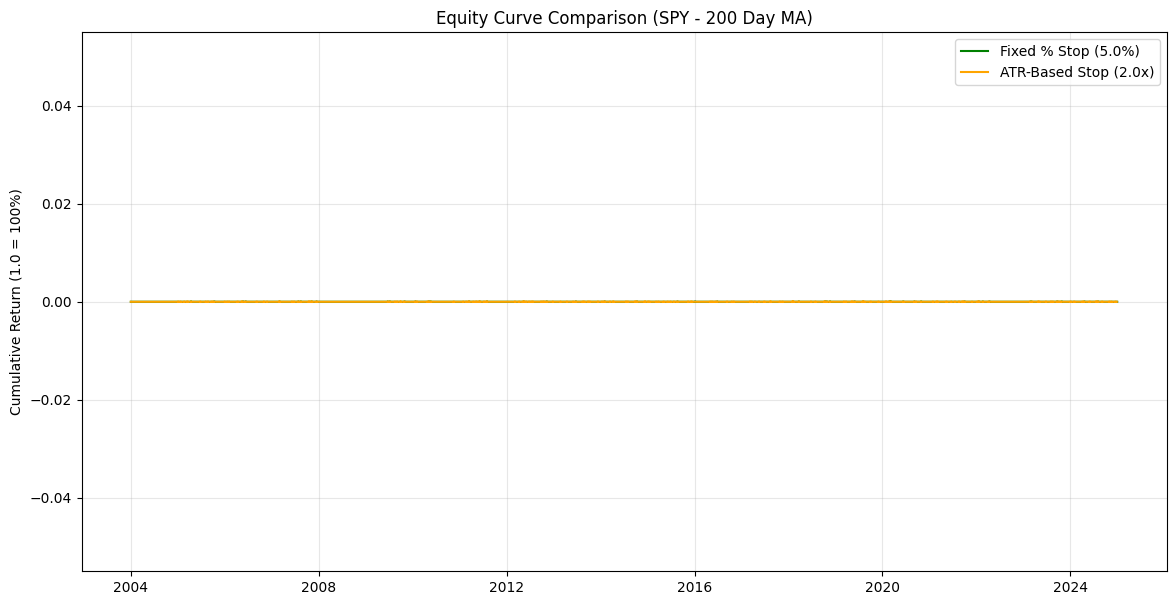

In [8]:
import matplotlib.pyplot as plt

def plot_stop_comparison(ticker, window=200):
    df = data_dict[ticker]

    # Run backtests
    trades_fixed = trade_ma_with_fixed_trailing_stop(df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
    trades_atr = trade_ma_with_atr_stop(df, window, epsilon=EPSILON, atr_multiplier=2.0)

    # Process returns into time-series
    def get_equity_curve(trades_df, full_index):
        if trades_df.empty: return pd.Series(0, index=full_index)
        rets = calculate_trade_returns(trades_df)
        equity = pd.Series(0.0, index=full_index)
        equity.loc[rets['ExitDate']] = rets['Return_Pct']
        return (1 + equity).cumprod() - 1

    equity_fixed = get_equity_curve(trades_fixed, df.index)
    equity_atr = get_equity_curve(trades_atr, df.index)

    # Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(equity_fixed, label=f'Fixed % Stop ({TRAILING_STOP_PCT*100}%)', color='green')
    plt.plot(equity_atr, label='ATR-Based Stop (2.0x)', color='orange')

    plt.title(f'Equity Curve Comparison ({ticker} - {window} Day MA)')
    plt.ylabel('Cumulative Return (1.0 = 100%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualize comparison for SPY
plot_stop_comparison('SPY', window=200)

### **Deep Dive: Why is ATR Underperforming?**
We will analyze two key factors:
1.  **Stop Distance**: How far away (in percentage terms) was the stop-loss from the price on average?
2.  **Stop-Out Analysis**: How many times was a trade closed specifically because the stop-loss was hit, versus the MA crossover signal?

--- Stop Loss Tightness Analysis: SPY ---
Average Fixed Stop Distance: 5.00%
Average ATR (2.0x) Stop Distance: 2.68%

Observation: The ATR stop is significantly TIGHTER (2.68%) than the fixed 5% stop.
This likely caused the strategy to exit trades during minor pullbacks that the fixed stop ignored.


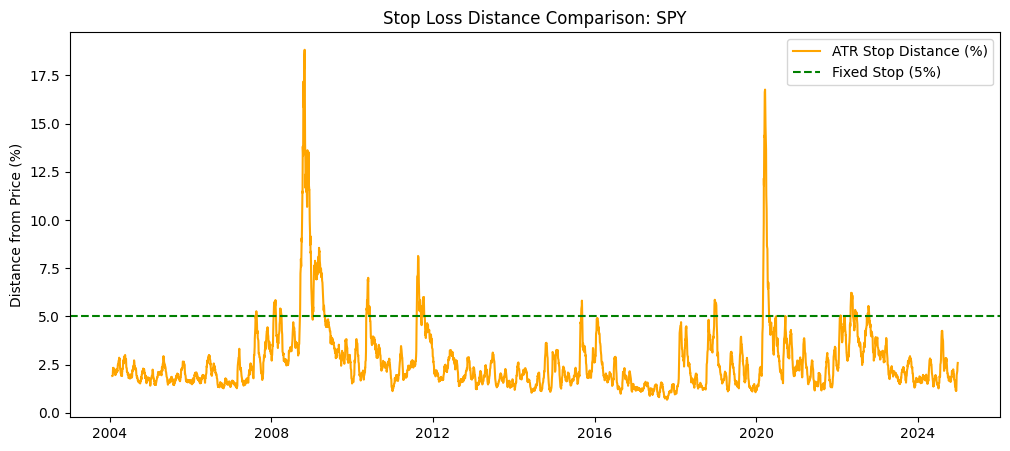

In [9]:
def analyze_stop_tightness(ticker, window=200):
    df = data_dict[ticker].copy()
    df = calculate_atr(df)

    # Calculate stop distances
    df['Fixed_Stop_Dist_Pct'] = 0.05  # 5%
    df['ATR_Stop_Dist_Pct'] = (df['ATR'] * 2.0) / df['Close']

    avg_atr_dist = df['ATR_Stop_Dist_Pct'].mean() * 100
    avg_fixed_dist = 5.0

    print(f"--- Stop Loss Tightness Analysis: {ticker} ---")
    print(f"Average Fixed Stop Distance: {avg_fixed_dist:.2f}%")
    print(f"Average ATR (2.0x) Stop Distance: {avg_atr_dist:.2f}%")

    if avg_atr_dist < avg_fixed_dist:
        print(f"\nObservation: The ATR stop is significantly TIGHTER ({avg_atr_dist:.2f}%) than the fixed 5% stop.")
        print("This likely caused the strategy to exit trades during minor pullbacks that the fixed stop ignored.")
    else:
        print(f"\nObservation: The ATR stop is WIDER than the fixed stop.")

    # Plot the distance over time
    plt.figure(figsize=(12, 5))
    plt.plot(df['ATR_Stop_Dist_Pct'] * 100, label='ATR Stop Distance (%)', color='orange')
    plt.axhline(y=5, color='green', linestyle='--', label='Fixed Stop (5%)')
    plt.title(f'Stop Loss Distance Comparison: {ticker}')
    plt.ylabel('Distance from Price (%)')
    plt.legend()
    plt.show()

analyze_stop_tightness('SPY')

### **Quantifying Performance Leak: Trade Duration & Churn**
We will now check if the ATR stop-outs resulted in shorter trade durations and more frequent 'whipsaws' (re-entering the same trend shortly after being stopped out).

In [10]:
def analyze_churn(ticker, window=200):
    df = data_dict[ticker]

    # Run backtests
    trades_fixed = trade_ma_with_fixed_trailing_stop(df, window, trailing_stop_pct=0.05)
    trades_atr = trade_ma_with_atr_stop(df, window, atr_multiplier=2.0)

    def get_stats(t_df):
        if t_df.empty: return 0, 0
        rets = calculate_trade_returns(t_df)
        # Approx duration by counting rows between entry and exit (every 2 rows is a trade)
        num_trades = len(rets)
        avg_duration = (len(df) / num_trades) if num_trades > 0 else 0
        return num_trades, avg_duration

    n_fixed, dur_fixed = get_stats(trades_fixed)
    n_atr, dur_atr = get_stats(trades_atr)

    print(f"--- Churn Analysis: {ticker} ---")
    print(f"Fixed 5% Stop: {n_fixed} trades | Approx. Avg Hold: {dur_fixed:.1f} days")
    print(f"ATR 2.0x Stop: {n_atr} trades | Approx. Avg Hold: {dur_atr:.1f} days")
    print(f"\nATR Result: {((n_atr/n_fixed)-1)*100:.1f}% more 'Churn' than Fixed Stop.")

analyze_churn('SPY')

--- Churn Analysis: SPY ---
Fixed 5% Stop: 48 trades | Approx. Avg Hold: 110.1 days
ATR 2.0x Stop: 195 trades | Approx. Avg Hold: 27.1 days

ATR Result: 306.2% more 'Churn' than Fixed Stop.


### **Comprehensive Comparison: Fixed % vs. Multiple ATR Multipliers**
In this step, we evaluate the performance sensitivity of the ATR trailing stop. We are comparing our baseline (Fixed 5%) against three levels of ATR aggression: 2.0x (Tight), 3.5x (Balanced), and 4.0x (Wide).

In [11]:
full_comparison_results = []
ATR_MULTIPLIERS = [2.0, 3.5, 4.0]

for ticker, df in data_dict.items():
    for window in [50, 200]:
        # 1. Fixed % Stop
        trades_fixed = trade_ma_with_fixed_trailing_stop(df, window, trailing_stop_pct=0.05)
        rets_fixed = calculate_trade_returns(trades_fixed)
        if not rets_fixed.empty:
            full_comparison_results.append({
                'Ticker': ticker, 'MA_Window': window, 'Stop_Type': 'Fixed 5%',
                'Total Return': (1 + rets_fixed['Return_Pct']).prod() - 1,
                'Max Drawdown': calculate_max_drawdown(rets_fixed['Return_Pct']),
                'Trades': len(rets_fixed)
            })

        # 2. ATR Multipliers
        for mult in ATR_MULTIPLIERS:
            trades_atr = trade_ma_with_atr_stop(df, window, atr_multiplier=mult)
            rets_atr = calculate_trade_returns(trades_atr)
            if not rets_atr.empty:
                full_comparison_results.append({
                    'Ticker': ticker, 'MA_Window': window, 'Stop_Type': f'ATR {mult}x',
                    'Total Return': (1 + rets_atr['Return_Pct']).prod() - 1,
                    'Max Drawdown': calculate_max_drawdown(rets_atr['Return_Pct']),
                    'Trades': len(rets_atr)
                })

# Aggregate and Display
final_comp_df = pd.DataFrame(full_comparison_results)
final_summary = final_comp_df.groupby(['MA_Window', 'Stop_Type']).agg({
    'Total Return': 'mean',
    'Max Drawdown': 'mean',
    'Trades': 'mean'
}).reset_index()

print("--- Combined Performance Table: Fixed vs. Multi-ATR ---")
display(final_summary.sort_values(by=['MA_Window', 'Total Return'], ascending=[True, False]))

--- Combined Performance Table: Fixed vs. Multi-ATR ---


,MA_Window,Stop_Type,Total Return,Max Drawdown,Trades
3,50,Fixed 5%,2.056533,-0.177103,62.4
2,50,ATR 4.0x,1.860491,-0.216125,70.0
1,50,ATR 3.5x,1.826443,-0.212194,78.0
0,50,ATR 2.0x,1.184202,-0.195907,145.6
6,200,ATR 4.0x,3.827440,-0.204130,74.8
5,200,ATR 3.5x,3.572982,-0.208091,88.6
7,200,Fixed 5%,3.300324,-0.193946,60.4
4,200,ATR 2.0x,2.738874,-0.247334,193.6


### **Comparison Summary: Fixed vs ATR Stop**
- **Volatility Sensitivity**: The ATR-based stop adjusts to market conditions. In high-volatility regimes, it widens to prevent premature stop-outs, potentially capturing longer trends.
- **Drawdown Protection**: Fixed percentage stops (e.g., 5%) provide a consistent floor but may be too tight for volatile tickers or too loose during calm periods.
- **Trade Frequency**: ATR stops often result in fewer, higher-quality trades as the dynamic buffer helps ignore noise.

# Section 3: Portfolio Aggregation and Backtesting

In [12]:
def calculate_sharpe_ratio(daily_returns, risk_free_rate=0.0):
    """Calculates Sharpe Ratio based on daily returns for accurate annualization."""
    if len(daily_returns) < 2 or daily_returns.std() == 0:
        return 0
    return ((daily_returns.mean() - risk_free_rate) / daily_returns.std()) * np.sqrt(252)

all_ticker_metrics = []

for ticker, ticker_data in data_dict.items():
    start_idx = 200
    eval_data = ticker_data.iloc[start_idx:].copy()

    # Helper to generate daily strategy returns series
    def get_daily_strategy_returns(df, trades_df):
        daily_rets = pd.Series(0.0, index=df.index)
        if trades_df.empty: return daily_rets

        # Mark positions: 1 for Long, 0 for Cash
        pos = pd.Series(0, index=df.index)
        for i in range(0, len(trades_df) - 1, 2):
            entry_date = trades_df.index[i]
            exit_date = trades_df.index[i+1]
            pos.loc[entry_date:exit_date] = 1

        # Strategy return = position (yesterday) * price change (today)
        daily_market_rets = df['Close'].pct_change().fillna(0)
        return pos.shift(1).fillna(0) * daily_market_rets

    # 1. Buy & Hold
    bh_daily = eval_data['Close'].pct_change().dropna()
    all_ticker_metrics.append({
        'Ticker': ticker, 'Strategy': 'Buy & Hold',
        'Total Return': (eval_data['Close'].iloc[-1] / eval_data['Close'].iloc[0]) - 1,
        'Max Drawdown': calculate_max_drawdown(bh_daily),
        'Sharpe Ratio': calculate_sharpe_ratio(bh_daily),
        'Total Trades': 1
    })

    # 2. Moving Average Strategies (All Windows)
    for window in MA_WINDOWS.keys():
        ma_trades = trade_ma_with_fixed_trailing_stop(ticker_data, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        ma_daily = get_daily_strategy_returns(ticker_data, ma_trades).iloc[start_idx:]
        if not ma_trades.empty:
            rets_df = calculate_trade_returns(ma_trades)
            all_ticker_metrics.append({
                'Ticker': ticker, 'Strategy': f'{window}-Day MA',
                'Total Return': (1 + rets_df['Return_Pct']).prod() - 1,
                'Max Drawdown': calculate_max_drawdown(ma_daily),
                'Sharpe Ratio': calculate_sharpe_ratio(ma_daily),
                'Total Trades': len(rets_df)
            })

    # 3. Persistent Confluence
    pst_trades = trade_confluence_persistent_state(ticker_data, window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)
    pst_daily = get_daily_strategy_returns(ticker_data, pst_trades).iloc[start_idx:]
    if not pst_trades.empty:
        pst_rets = calculate_trade_returns(pst_trades)
        all_ticker_metrics.append({
            'Ticker': ticker, 'Strategy': 'Persistent Confluence',
            'Total Return': (1 + pst_rets['Return_Pct']).prod() - 1,
            'Max Drawdown': calculate_max_drawdown(pst_daily),
            'Sharpe Ratio': calculate_sharpe_ratio(pst_daily),
            'Total Trades': len(pst_rets)
        })

master_comparison_df = pd.DataFrame(all_ticker_metrics)
global_summary = master_comparison_df.groupby('Strategy').agg({
    'Total Return': 'mean', 'Max Drawdown': 'mean', 'Sharpe Ratio': 'mean', 'Total Trades': 'sum'
}).reset_index()

display(global_summary.sort_values(by='Sharpe Ratio', ascending=False))

,Strategy,Total Return,Max Drawdown,Sharpe Ratio,Total Trades
2,200-Day MA,3.300324,-0.241904,0.626770,302
4,Buy & Hold,7.909880,-0.549111,0.619020,5
5,Persistent Confluence,3.862115,-0.344114,0.586305,27
3,50-Day MA,2.056533,-0.244108,0.546519,312
0,100-Day MA,1.943410,-0.260845,0.503904,301
1,20-Day MA,2.135633,-0.328320,0.490246,421


### **Detailed Performance Comparison by Ticker**
This table provides a granular look at how each strategy (Buy & Hold, various MAs, and RSI) performed for each individual asset in the portfolio.

In [13]:
# Pivot the master dataframe to easily compare Total Return across tickers and strategies
ticker_comparison_pivot = master_comparison_df.pivot_table(
    index='Strategy',
    columns='Ticker',
    values='Total Return'
)

print("--- Total Return Comparison by Ticker ---")
display(ticker_comparison_pivot)

# Also show the Max Drawdown comparison
mdd_comparison_pivot = master_comparison_df.pivot_table(
    index='Strategy',
    columns='Ticker',
    values='Max Drawdown'
)

print("\n--- Max Drawdown Comparison by Ticker ---")
display(mdd_comparison_pivot)

--- Total Return Comparison by Ticker ---


Ticker,DIA,IWM,QQQ,SPY,VTI
Strategy,,,,,
100-Day MA,1.412779,0.692804,3.260297,2.118687,2.232482
20-Day MA,0.920122,0.862500,5.272106,1.786551,1.836886
200-Day MA,2.524193,1.735937,6.349168,2.688330,3.203992
50-Day MA,0.994564,0.691158,4.539386,1.894496,2.163061
Buy & Hold,5.790416,4.133278,15.921479,6.799030,6.905194
Persistent Confluence,3.160169,2.271932,7.329183,3.139954,3.409338



--- Max Drawdown Comparison by Ticker ---


Ticker,DIA,IWM,QQQ,SPY,VTI
Strategy,,,,,
100-Day MA,-0.217486,-0.306669,-0.273296,-0.263254,-0.243519
20-Day MA,-0.281994,-0.381899,-0.300816,-0.322313,-0.354577
200-Day MA,-0.185136,-0.338198,-0.261368,-0.200053,-0.224767
50-Day MA,-0.261359,-0.354802,-0.200198,-0.210392,-0.193792
Buy & Hold,-0.518684,-0.586400,-0.534040,-0.551894,-0.554538
Persistent Confluence,-0.366961,-0.380839,-0.285593,-0.337173,-0.350003


# Section 4: Performance Visualization

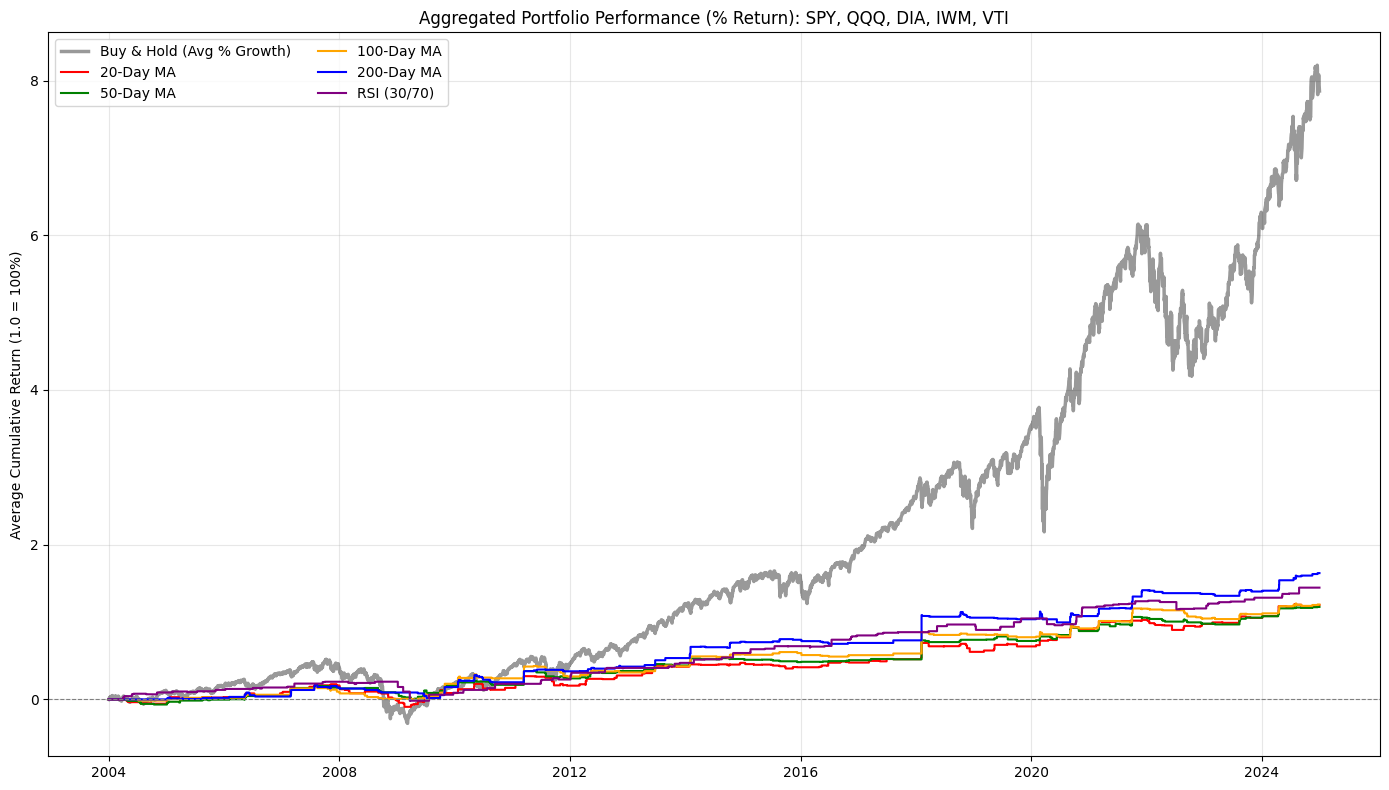

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize storage
portfolio_returns = {}

# 1. Calculate Portfolio Benchmark (Cumulative % Growth)
bh_rets_list = []
for ticker, ticker_df in data_dict.items():
    bh_growth = (ticker_df['Close'] / ticker_df['Close'].iloc[0]) - 1
    bh_rets_list.append(bh_growth)

portfolio_returns['Buy & Hold'] = pd.concat(bh_rets_list, axis=1).mean(axis=1)

# 2. Calculate Portfolio MA Strategies (Fixed function names)
for window in MA_WINDOWS.keys():
    ma_rets_list = []
    for ticker, ticker_df in data_dict.items():
        trade_df = trade_ma_with_fixed_trailing_stop(ticker_df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        if not trade_df.empty:
            returns_df = calculate_trade_returns(trade_df)
            temp_series = pd.Series(0.0, index=ticker_df.index)
            temp_series.loc[returns_df['ExitDate']] = returns_df['Return_Pct'].values
            ma_rets_list.append(temp_series.cumsum())
    if ma_rets_list:
        portfolio_returns[f'{window}-Day MA'] = pd.concat(ma_rets_list, axis=1).mean(axis=1)

# 3. Calculate Portfolio RSI Strategy
rsi_rets_list = []
for ticker, ticker_df in data_dict.items():
    trade_df_rsi = add_rsi_signals(ticker_df, oversold=RSI_OVERSOLD, overbought=RSI_OVERBOUGHT)
    if not trade_df_rsi.empty:
        returns_df_rsi = calculate_trade_returns(trade_df_rsi)
        temp_series = pd.Series(0.0, index=ticker_df.index)
        temp_series.loc[returns_df_rsi['ExitDate']] = returns_df_rsi['Return_Pct'].values
        rsi_rets_list.append(temp_series.cumsum())
if rsi_rets_list:
    portfolio_returns['RSI (30/70)'] = pd.concat(rsi_rets_list, axis=1).mean(axis=1)

# Plotting
plt.figure(figsize=(14, 8))
plt.plot(portfolio_returns['Buy & Hold'], label='Buy & Hold (Avg % Growth)', color='black', linewidth=2.5, alpha=0.4)

for label, series in portfolio_returns.items():
    if label == 'Buy & Hold': continue
    color = 'purple'
    if '-Day MA' in label:
        window_size = int(label.split('-')[0])
        color = MA_WINDOWS.get(window_size, 'purple')

    plt.step(series.index, series, label=label, color=color, where='post')

ticker_str = ', '.join(TARGET_TICKERS)
plt.title(f'Aggregated Portfolio Performance (% Return): {ticker_str}')
plt.ylabel('Average Cumulative Return (1.0 = 100%)')
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Strategy: Confluence of Trend and Momentum**
This strategy combines the **200-Day Moving Average** (as a long-term trend filter) with **RSI** (as a tactical entry/exit signal).
- **BUY**: Price > 200-Day MA AND RSI < 30 (Buying a dip in an uptrend).
- **SELL**: Price < 200-Day MA AND RSI > 70 (Selling a rip in a downtrend).

In [15]:
# Cell removed: Logic is now part of the consolidated backtest in earlier cells.

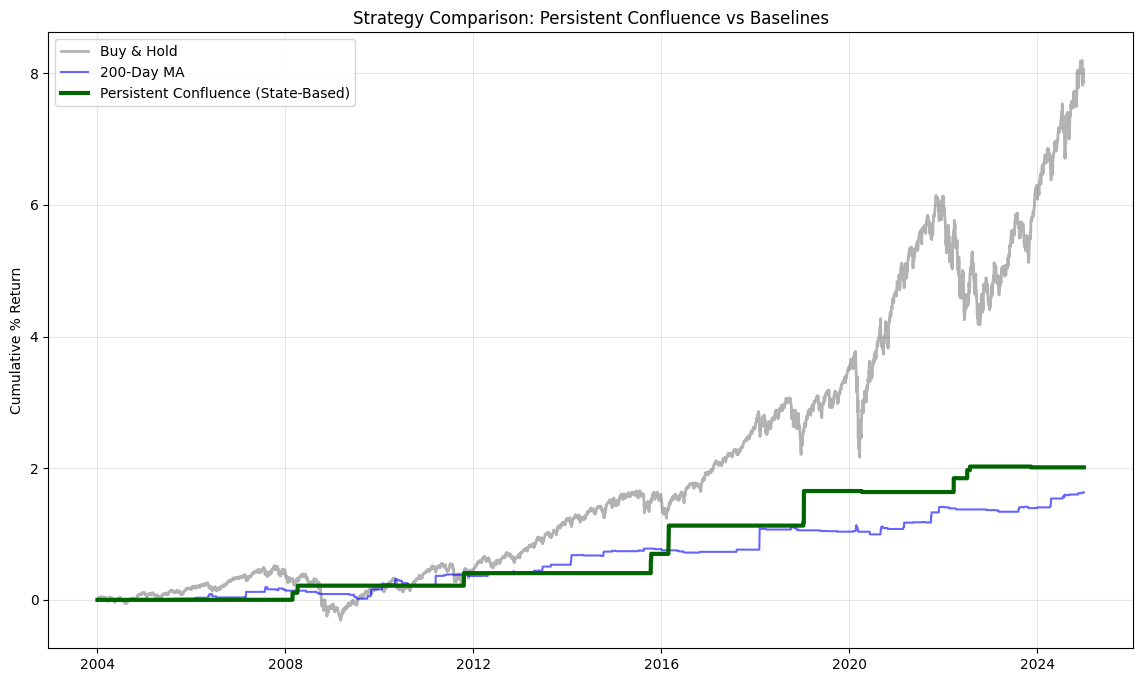

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Portfolio Equity Curves
portfolio_equity = {}

# Buy & Hold Benchmark
bh_list = []
for t in TARGET_TICKERS:
    bh_list.append((data_dict[t]['Close'] / data_dict[t]['Close'].iloc[0]) - 1)
portfolio_equity['Buy & Hold'] = pd.concat(bh_list, axis=1).mean(axis=1)

# Standard 200-Day MA
ma_list = []
for t in TARGET_TICKERS:
    tr = trade_ma_with_fixed_trailing_stop(data_dict[t], 200, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
    if not tr.empty:
        rets = calculate_trade_returns(tr)
        s = pd.Series(0.0, index=data_dict[t].index)
        s.loc[rets['ExitDate']] = rets['Return_Pct'].values
        ma_list.append(s.cumsum())
portfolio_equity['200-Day MA'] = pd.concat(ma_list, axis=1).mean(axis=1)

# Persistent Confluence
pst_list = []
for t in TARGET_TICKERS:
    tr = trade_confluence_persistent_state(data_dict[t], window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)
    if not tr.empty:
        rets = calculate_trade_returns(tr)
        s = pd.Series(0.0, index=data_dict[t].index)
        s.loc[rets['ExitDate']] = rets['Return_Pct'].values
        pst_list.append(s.cumsum())
portfolio_equity['Persistent Confluence'] = pd.concat(pst_list, axis=1).mean(axis=1)

# 2. Visualization
plt.figure(figsize=(14, 8))
plt.plot(portfolio_equity['Buy & Hold'], label='Buy & Hold', color='black', linewidth=2, alpha=0.3)
plt.plot(portfolio_equity['200-Day MA'], label='200-Day MA', color='blue', alpha=0.6)
plt.plot(portfolio_equity['Persistent Confluence'], label='Persistent Confluence (State-Based)', color='darkgreen', linewidth=3)

plt.title('Strategy Comparison: Persistent Confluence vs Baselines')
plt.ylabel('Cumulative % Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Section 5: Individual Ticker Performance Deep-Dive

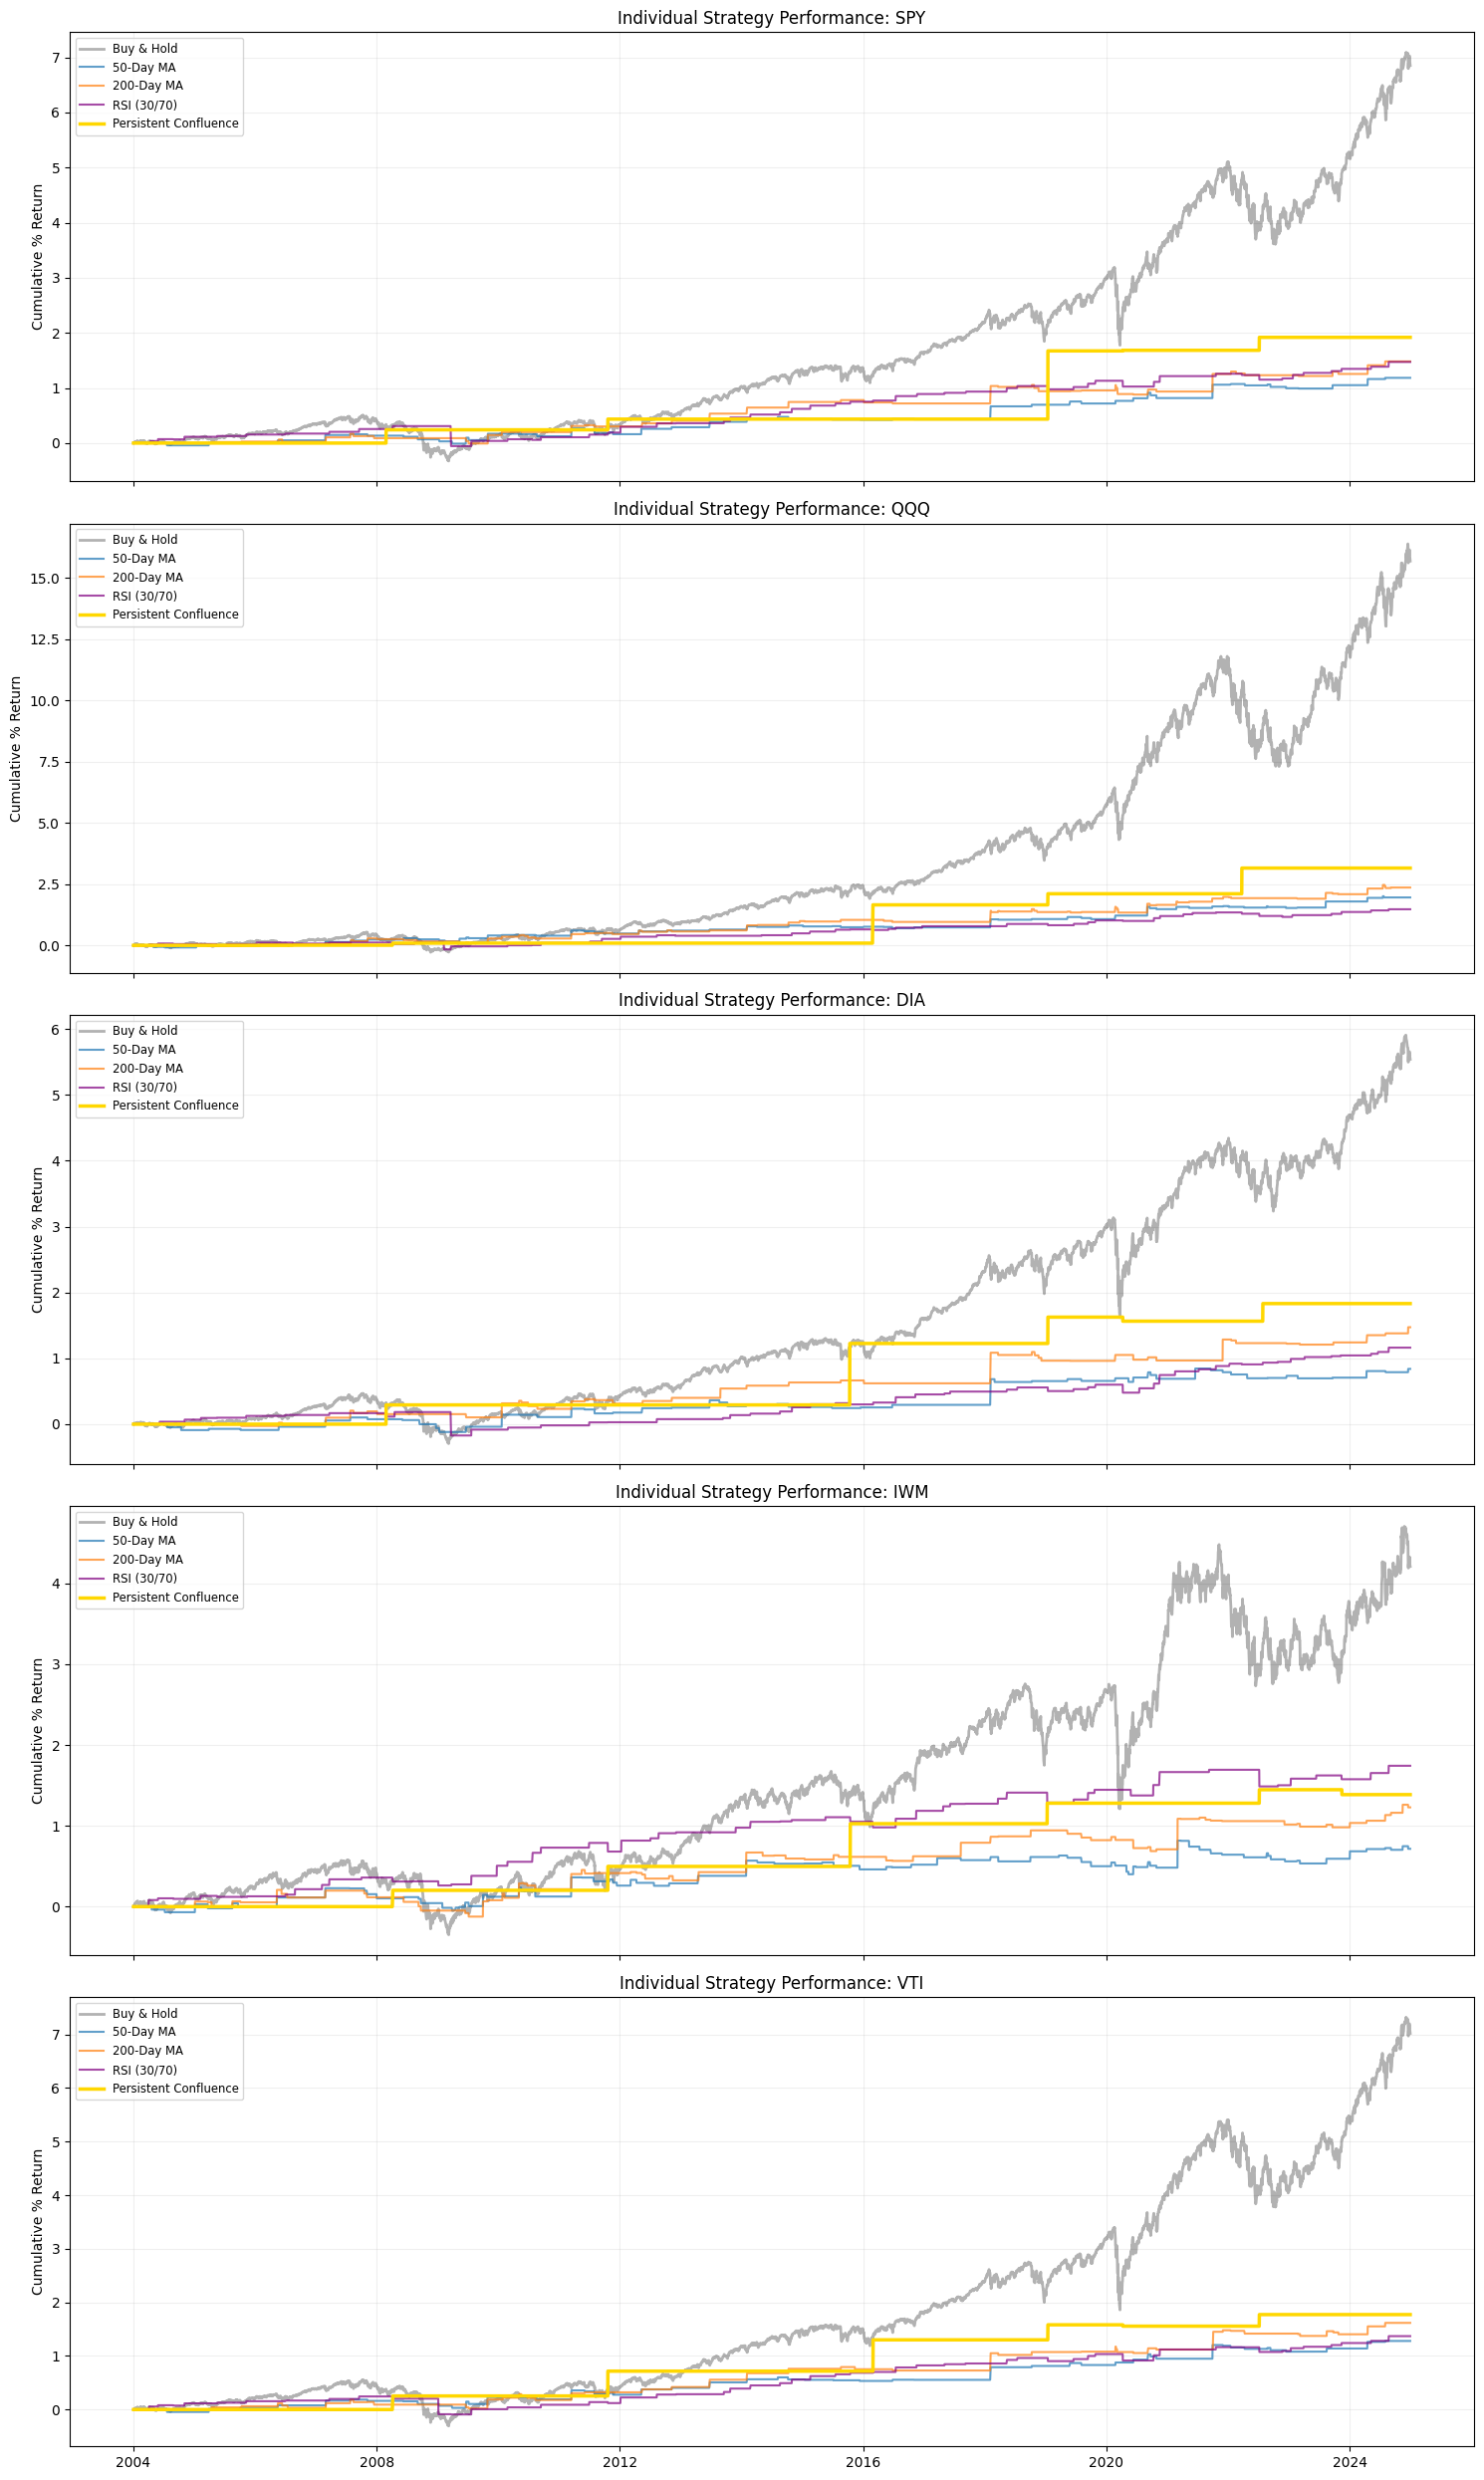

In [17]:
import matplotlib.pyplot as plt

# Set up a grid for individual ticker subplots
fig, axes = plt.subplots(nrows=len(TARGET_TICKERS), ncols=1, figsize=(15, 5 * len(TARGET_TICKERS)), sharex=True)

for i, ticker in enumerate(TARGET_TICKERS):
    ticker_df = data_dict[ticker]
    ax = axes[i]

    # 1. Buy & Hold for this ticker
    bh_growth = (ticker_df['Close'] / ticker_df['Close'].iloc[0]) - 1
    ax.plot(bh_growth, label='Buy & Hold', color='black', linewidth=2, alpha=0.3)

    # 2. MA Strategies for this ticker
    for window in [50, 200]: # Focus on key windows for clarity
        trade_df = trade_ma_with_fixed_trailing_stop(ticker_df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        if not trade_df.empty:
            rets = calculate_trade_returns(trade_df)
            series = pd.Series(0.0, index=ticker_df.index)
            series.loc[rets['ExitDate']] = rets['Return_Pct'].values
            ax.plot(series.cumsum(), label=f'{window}-Day MA', alpha=0.7)

    # 3. RSI Strategy for this ticker
    trade_df_rsi = add_rsi_signals(ticker_df, oversold=RSI_OVERSOLD, overbought=RSI_OVERBOUGHT)
    if not trade_df_rsi.empty:
        rets_rsi = calculate_trade_returns(trade_df_rsi)
        series_rsi = pd.Series(0.0, index=ticker_df.index)
        series_rsi.loc[rets_rsi['ExitDate']] = rets_rsi['Return_Pct'].values
        ax.plot(series_rsi.cumsum(), label='RSI (30/70)', color='purple', alpha=0.7)

    # 4. Persistent Confluence Strategy for this ticker (Updated from standard confluence)
    trade_df_conf = trade_confluence_persistent_state(ticker_df, window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)
    if not trade_df_conf.empty:
        rets_conf = calculate_trade_returns(trade_df_conf)
        series_conf = pd.Series(0.0, index=ticker_df.index)
        series_conf.loc[rets_conf['ExitDate']] = rets_conf['Return_Pct'].values
        ax.plot(series_conf.cumsum(), label='Persistent Confluence', color='gold', linewidth=2.5)

    ax.set_title(f'Individual Strategy Performance: {ticker}')
    ax.set_ylabel('Cumulative % Return')
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Section 6: RSI Variant and Confluence Analysis

In [18]:
# Cell kept for structural flow; RSI logic consolidated above.

In [19]:
# Apply RSI calculation and preview the results using a representative ticker (SPY)
data = data_dict['SPY'].copy()
data = calculate_rsi(data)
display(data[['Close', 'RSI']].tail(5))

Price,Close,RSI
Date,,
2024-12-23,584.680420,43.148886
2024-12-24,591.179077,46.097923
2024-12-26,591.218445,46.981803
2024-12-27,584.994934,40.972795
2024-12-30,578.319336,38.596095


In [20]:
rsi_variants = [
    (RSI_OVERSOLD, RSI_OVERBOUGHT),
    (RSI_OVERSOLD - 10, RSI_OVERBOUGHT + 10),
    (RSI_OVERSOLD + 10, RSI_OVERBOUGHT - 10)
]

rsi_results = []

# We use SPY as our representative benchmark for testing these variants
# to keep the comparison clean before applying the best one to the whole portfolio.
benchmark_ticker = 'SPY'
test_df = data_dict[benchmark_ticker]

for oversold, overbought in rsi_variants:
    trade_df_rsi = add_rsi_signals(test_df, oversold=oversold, overbought=overbought)

    if not trade_df_rsi.empty:
        returns_df_rsi = calculate_trade_returns(trade_df_rsi)

        rsi_results.append({
            'Strategy': f'RSI ({oversold}/{overbought})',
            'Oversold': oversold,
            'Overbought': overbought,
            'Total Trades': len(returns_df_rsi),
            'Total Return': returns_df_rsi['Return_Pct'].sum(),
            'Win Rate (%)': (returns_df_rsi['Return_Pct'] > 0).mean() * 100 if len(returns_df_rsi) > 0 else 0
        })

print(f"--- RSI Strategy Variants Summary ({benchmark_ticker}) ---")
rsi_summary_df = pd.DataFrame(rsi_results)
display(rsi_summary_df)

--- RSI Strategy Variants Summary (SPY) ---


,Strategy,Oversold,Overbought,Total Trades,Total Return,Win Rate (%)
0,RSI (30/70),30,70,53,1.472641,84.905660
1,RSI (20/80),20,80,14,0.520890,78.571429
2,RSI (40/60),40,60,100,1.384183,78.000000


In [21]:
all_results = []

# We iterate through all tickers in our portfolio to build the summary
for ticker, df in data_dict.items():
    # MA Results
    for window in MA_WINDOWS.keys():
        trade_df = trade_ma_with_fixed_trailing_stop(df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        if not trade_df.empty:
            rets = calculate_trade_returns(trade_df)
            all_results.append({
                'Ticker': ticker,
                'Strategy': f'MA {window}',
                'Total Return': rets['Return_Pct'].sum(),
                'Total Trades': len(rets),
                'Win Rate (%)': (rets['Return_Pct'] > 0).mean() * 100 if len(rets) > 0 else 0,
                'Max Drawdown (Trades)': calculate_max_drawdown(rets['Return_Pct'])
            })

    # RSI Variant Results
    for oversold, overbought in rsi_variants:
        trade_df_rsi = add_rsi_signals(df, oversold=oversold, overbought=overbought)
        if not trade_df_rsi.empty:
            rets_rsi = calculate_trade_returns(trade_df_rsi)
            all_results.append({
                'Ticker': ticker,
                'Strategy': f'RSI ({oversold}/{overbought})',
                'Total Return': rets_rsi['Return_Pct'].sum(),
                'Total Trades': len(rets_rsi),
                'Win Rate (%)': (rets_rsi['Return_Pct'] > 0).mean() * 100 if len(rets_rsi) > 0 else 0,
                'Max Drawdown (Trades)': calculate_max_drawdown(rets_rsi['Return_Pct'])
            })

full_comparison_df = pd.DataFrame(all_results)
# Display aggregated results grouped by strategy to see performance across the whole portfolio
portfolio_summary = full_comparison_df.groupby('Strategy').agg({
    'Total Return': 'mean',
    'Total Trades': 'sum',
    'Win Rate (%)': 'mean',
    'Max Drawdown (Trades)': 'mean'
}).reset_index()

display(portfolio_summary.sort_values(by='Total Return', ascending=False))

,Strategy,Total Return,Total Trades,Win Rate (%),Max Drawdown (Trades)
2,MA 200,1.632562,302,52.922549,-0.193946
5,RSI (30/70),1.444574,267,81.822835,-0.309483
6,RSI (40/60),1.339800,499,75.267162,-0.287319
0,MA 100,1.226832,301,48.616084,-0.184730
1,MA 20,1.219407,421,48.566511,-0.285552
3,MA 50,1.195191,312,50.414814,-0.177103
4,RSI (20/80),0.618505,84,77.864464,-0.234062


In [22]:
def trade_confluence_persistent_state(df, window_ma=200, rsi_os=30, rsi_ob=70, epsilon=0.02):
    """
    Persistent Confluence Strategy:
    Unlike standard confluence which triggers on a 'touch' of a level, this logic treats
    indicators as 'States'.

    - BUY: Occurs only when the price is currently in an 'Uptrend State' (Price > MA + Epsilon)
           AND the RSI is currently in an 'Oversold State' (RSI < 30).
    - SELL: Occurs when the price enters a 'Downtrend State' (Price < MA - Epsilon)
            AND the RSI is in an 'Overbought State' (RSI > 70).

    This ensures we only enter high-probability setups where a long-term trend
    and a short-term exhaustion signal coexist.
    """
    # 1. Calculate indicators
    ma_col = f'MA_{window_ma}'
    if ma_col not in df.columns:
        df[ma_col] = df['Close'].rolling(window=window_ma).mean()
    if 'RSI' not in df.columns:
        df = calculate_rsi(df)

    result_df = df.copy()
    result_df['Trade'] = None
    last_signal = None

    # 2. Define States (Booleans)
    result_df['In_Uptrend'] = result_df['Close'] > (result_df[ma_col] * (1 + epsilon))
    result_df['In_Downtrend'] = result_df['Close'] < (result_df[ma_col] * (1 - epsilon))
    result_df['Is_Oversold'] = result_df['RSI'] < rsi_os
    result_df['Is_Overbought'] = result_df['RSI'] > rsi_ob

    # 3. Iterate and Trigger on Confluence of States
    for i in range(1, len(result_df)):
        if result_df['In_Uptrend'].iloc[i] and result_df['Is_Oversold'].iloc[i]:
            if last_signal != 'BUY':
                result_df.at[result_df.index[i], 'Trade'] = 'BUY'
                last_signal = 'BUY'
        elif result_df['In_Downtrend'].iloc[i] and result_df['Is_Overbought'].iloc[i]:
            if last_signal != 'SELL':
                result_df.at[result_df.index[i], 'Trade'] = 'SELL'
                last_signal = 'SELL'

    return result_df[result_df['Trade'].notna()][['Close', 'Trade']]

In [23]:

# Re-run test for SPY
test_ticker = 'SPY'
state_confluence_df = trade_confluence_persistent_state(data_dict[test_ticker], window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)

if not state_confluence_df.empty:
    res = calculate_trade_returns(state_confluence_df)
    print(f"--- Persistent State Confluence Strategy ({test_ticker}: MA 200 + RSI 30/70) ---")
    display(pd.DataFrame([{
        'Strategy': 'Persistent State Confluence',
        'Total Return': res['Return_Pct'].sum(),
        'Total Trades': len(res),
        'Win Rate (%)': (res['Return_Pct'] > 0).mean() * 100
    }]))

--- Persistent State Confluence Strategy (SPY: MA 200 + RSI 30/70) ---


,Strategy,Total Return,Total Trades,Win Rate (%)
0,Persistent State Confluence,1.919066,5,100.0


### **Consolidated Backtest: Multi-Ticker Strategy Comparison**
This analysis aggregates performance for **SPY, QQQ, DIA, IWM, and VTI** over the full dataset to evaluate the robustness of our strategy variants.

In [24]:
def calculate_sharpe_ratio(returns_series, risk_free_rate=0.0):
    """Standardized Sharpe Ratio for daily returns with 252-day annualization."""
    if returns_series.empty or returns_series.std() == 0:
        return 0
    return ((returns_series.mean() - risk_free_rate) / returns_series.std()) * np.sqrt(252)

def get_daily_strategy_returns(df, trades_df):
    """Converts entry/exit signals into a daily returns stream."""
    daily_rets = pd.Series(0.0, index=df.index)
    if trades_df.empty: return daily_rets
    pos = pd.Series(0, index=df.index)
    for i in range(0, len(trades_df) - 1, 2):
        entry_date = trades_df.index[i]
        exit_date = trades_df.index[i+1]
        pos.loc[entry_date:exit_date] = 1
    return pos.shift(1).fillna(0) * df['Close'].pct_change().fillna(0)

def run_full_backtest(data_dict, ma_windows, epsilon, stop_pct, rsi_os, rsi_ob, warm_up):
    """
    Aggregates all strategies into a single function with granular trade-level statistics.
    Standardizes the evaluation period by skipping the 'warm_up' period for indicator stabilization.
    """
    results = []

    for ticker, df in data_dict.items():
        # Standardize evaluation data
        eval_df = df.iloc[warm_up:].copy()

        # 1. Buy & Hold Benchmark
        bh_rets = eval_df['Close'].pct_change().dropna()
        results.append({
            'Ticker': ticker, 'Strategy': 'Buy & Hold',
            'Total Return': (eval_df['Close'].iloc[-1] / eval_df['Close'].iloc[0]) - 1,
            'Max Drawdown': calculate_max_drawdown(bh_rets),
            'Sharpe Ratio': calculate_sharpe_ratio(bh_rets),
            'Win Rate (%)': 100.0,
            'Exp Return/Trade': (eval_df['Close'].iloc[-1] / eval_df['Close'].iloc[0]) - 1,
            'Std Dev/Trade': 0.0,
            'Trades': 1
        })

        # 2. Moving Average Strategies
        for window in ma_windows:
            trades = trade_ma_with_fixed_trailing_stop(df, window, epsilon=epsilon, trailing_stop_pct=stop_pct)
            if not trades.empty:
                # Slice daily returns to start after the warm-up period
                daily_rets = get_daily_strategy_returns(df, trades).iloc[warm_up:]
                rets_df = calculate_trade_returns(trades)
                results.append({
                    'Ticker': ticker, 'Strategy': f'{window}-Day MA',
                    'Total Return': (1 + daily_rets).prod() - 1,
                    'Max Drawdown': calculate_max_drawdown(daily_rets),
                    'Sharpe Ratio': calculate_sharpe_ratio(daily_rets),
                    'Win Rate (%)': (rets_df['Return_Pct'] > 0).mean() * 100,
                    'Exp Return/Trade': rets_df['Return_Pct'].mean(),
                    'Std Dev/Trade': rets_df['Return_Pct'].std(),
                    'Trades': len(rets_df)
                })

        # 3. Persistent Confluence
        pst_trades = trade_confluence_persistent_state(df, window_ma=200, rsi_os=rsi_os, rsi_ob=rsi_ob, epsilon=epsilon)
        if not pst_trades.empty:
            daily_rets_conf = get_daily_strategy_returns(df, pst_trades).iloc[warm_up:]
            rets_conf = calculate_trade_returns(pst_trades)
            results.append({
                'Ticker': ticker, 'Strategy': 'Persistent Confluence',
                'Total Return': (1 + daily_rets_conf).prod() - 1,
                'Max Drawdown': calculate_max_drawdown(daily_rets_conf),
                'Sharpe Ratio': calculate_sharpe_ratio(daily_rets_conf),
                'Win Rate (%)': (rets_conf['Return_Pct'] > 0).mean() * 100,
                'Exp Return/Trade': rets_conf['Return_Pct'].mean(),
                'Std Dev/Trade': rets_conf['Return_Pct'].std(),
                'Trades': len(rets_conf)
            })

    return pd.DataFrame(results)

# Run the consolidated backtest with explicit 200-day warm-up
master_results = run_full_backtest(data_dict, MA_WINDOWS.keys(), EPSILON, TRAILING_STOP_PCT, RSI_OVERSOLD, RSI_OVERBOUGHT, warm_up=200)

# Display aggregated results
portfolio_summary = master_results.groupby('Strategy').agg({
    'Total Return': 'mean',
    'Max Drawdown': 'mean',
    'Sharpe Ratio': 'mean',
    'Win Rate (%)': 'mean',
    'Exp Return/Trade': 'mean',
    'Std Dev/Trade': 'mean',
    'Trades': 'sum'
}).sort_values('Sharpe Ratio', ascending=False)

print("--- Final Standardized Portfolio Performance (200-Day Warmup Applied) ---")
display(portfolio_summary)

--- Final Standardized Portfolio Performance (200-Day Warmup Applied) ---


,Total Return,Max Drawdown,Sharpe Ratio,Win Rate (%),Exp Return/Trade,Std Dev/Trade,Trades
Strategy,,,,,,,
200-Day MA,3.474048,-0.241904,0.626770,52.922549,0.028024,0.090015,302
Buy & Hold,7.909880,-0.549111,0.619020,100.000000,7.909880,0.000000,5
Persistent Confluence,3.908397,-0.344114,0.586305,89.333333,0.381568,0.382952,27
50-Day MA,2.398377,-0.244108,0.546519,50.414814,0.020178,0.074595,312
100-Day MA,2.028566,-0.260845,0.503904,48.616084,0.021894,0.083009,301
20-Day MA,2.192677,-0.328320,0.490246,48.566511,0.014858,0.067764,421


In [25]:
import pandas as pd

summary_stats = global_summary.copy()
# Extracting the Confluence results from both dataframes for direct comparison
summary_16a1 = portfolio_summary.loc[['Persistent Confluence']] if 'Persistent Confluence' in portfolio_summary.index else pd.DataFrame()
summary_bff = summary_stats[summary_stats['Strategy'] == 'Persistent Confluence'].set_index('Strategy')

print("--- Comparison of Persistent Confluence Metrics ---")
comparison = pd.concat([summary_16a1, summary_bff], keys=['Cell 16a1fbbd', 'Cell bffdb8ef'])
display(comparison)

--- Comparison of Persistent Confluence Metrics ---


,,Total Return,Max Drawdown,Sharpe Ratio,Win Rate (%),Exp Return/Trade,Std Dev/Trade,Trades,Total Trades
,Strategy,,,,,,,,
Cell 16a1fbbd,Persistent Confluence,3.908397,-0.344114,0.586305,89.333333,0.381568,0.382952,27.0,NaN
Cell bffdb8ef,Persistent Confluence,3.862115,-0.344114,0.586305,NaN,NaN,NaN,NaN,27.0


In [26]:
print("--- Verifying Persistent Confluence Metrics ---")
display(summary_stats.sort_values(by='Sharpe Ratio', ascending=False))

--- Verifying Persistent Confluence Metrics ---


,Strategy,Total Return,Max Drawdown,Sharpe Ratio,Total Trades
2,200-Day MA,3.300324,-0.241904,0.626770,302
4,Buy & Hold,7.909880,-0.549111,0.619020,5
5,Persistent Confluence,3.862115,-0.344114,0.586305,27
3,50-Day MA,2.056533,-0.244108,0.546519,312
0,100-Day MA,1.943410,-0.260845,0.503904,301
1,20-Day MA,2.135633,-0.328320,0.490246,421


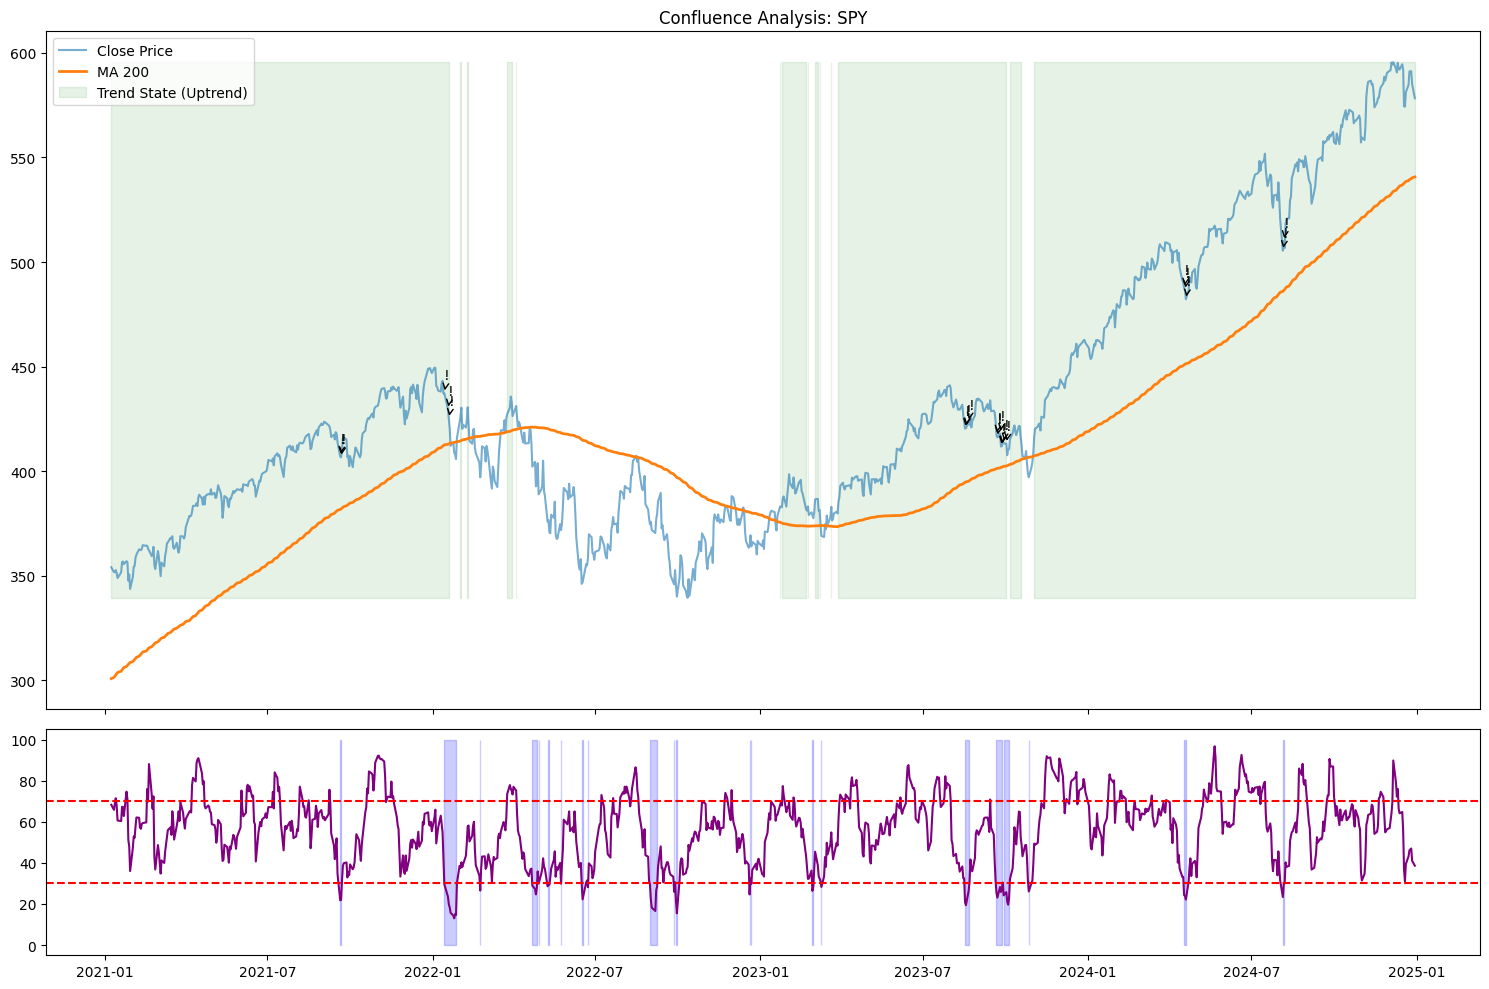

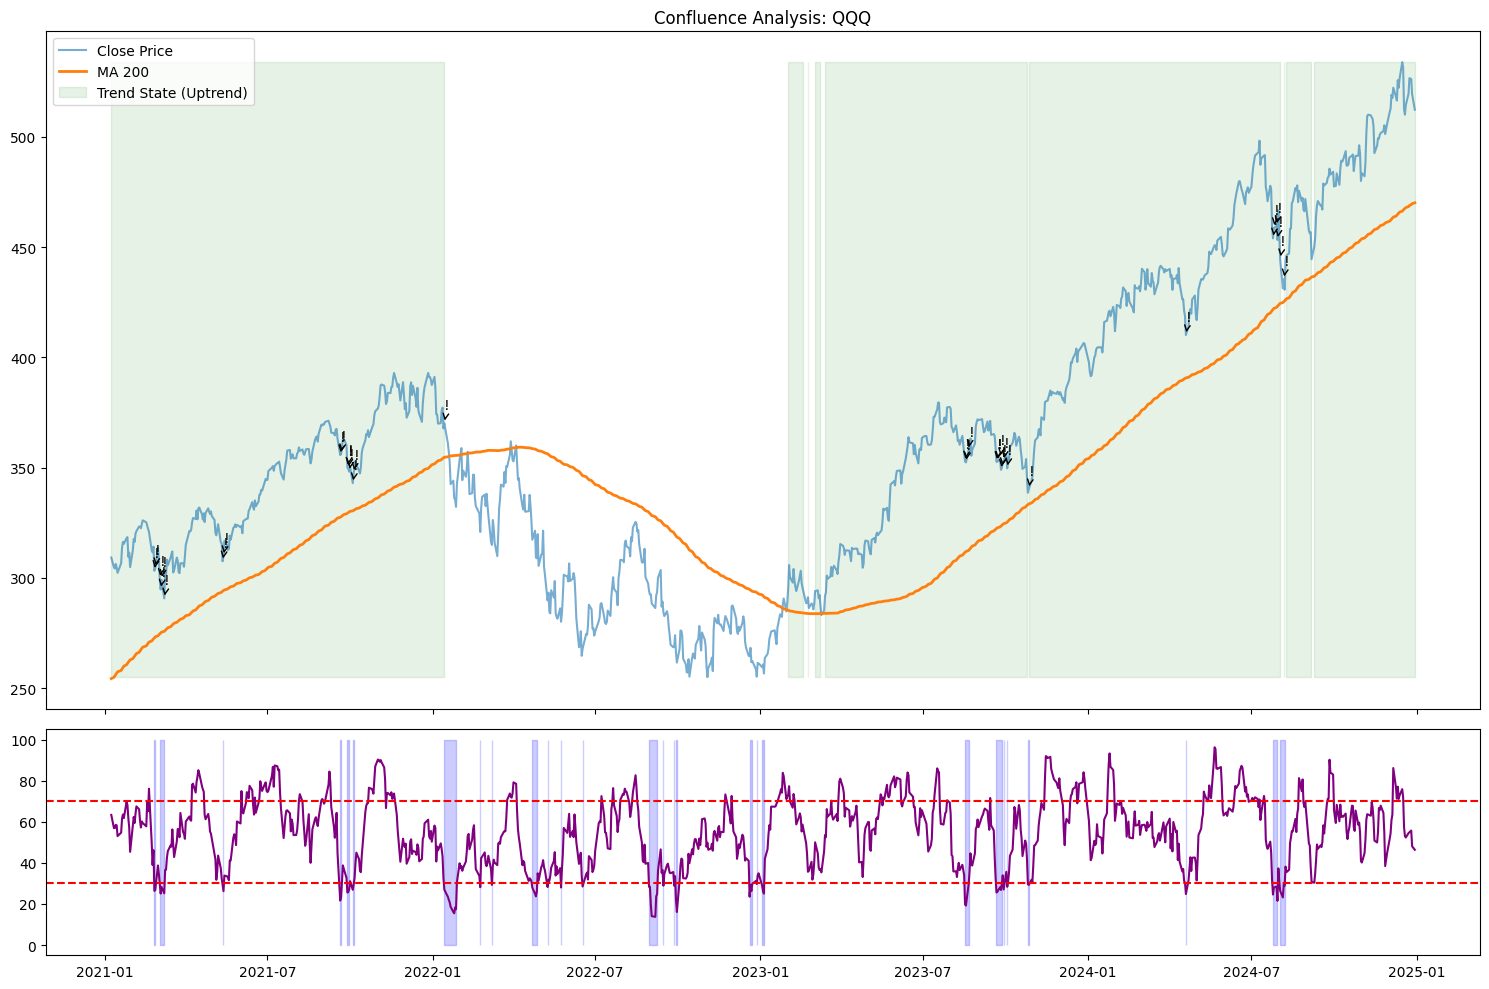

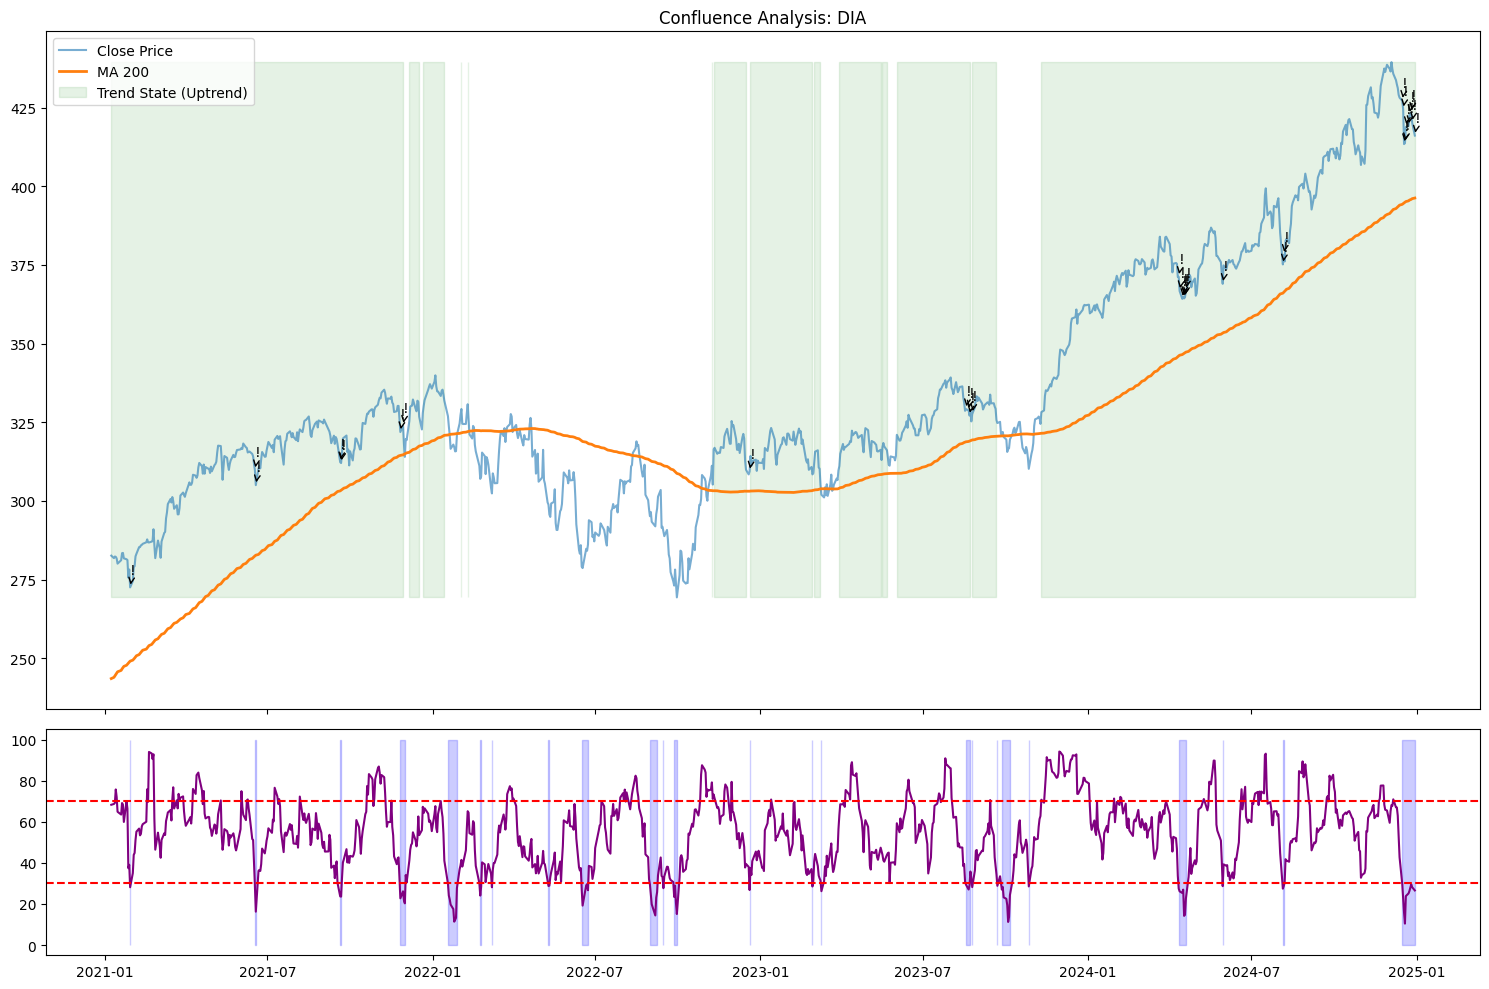

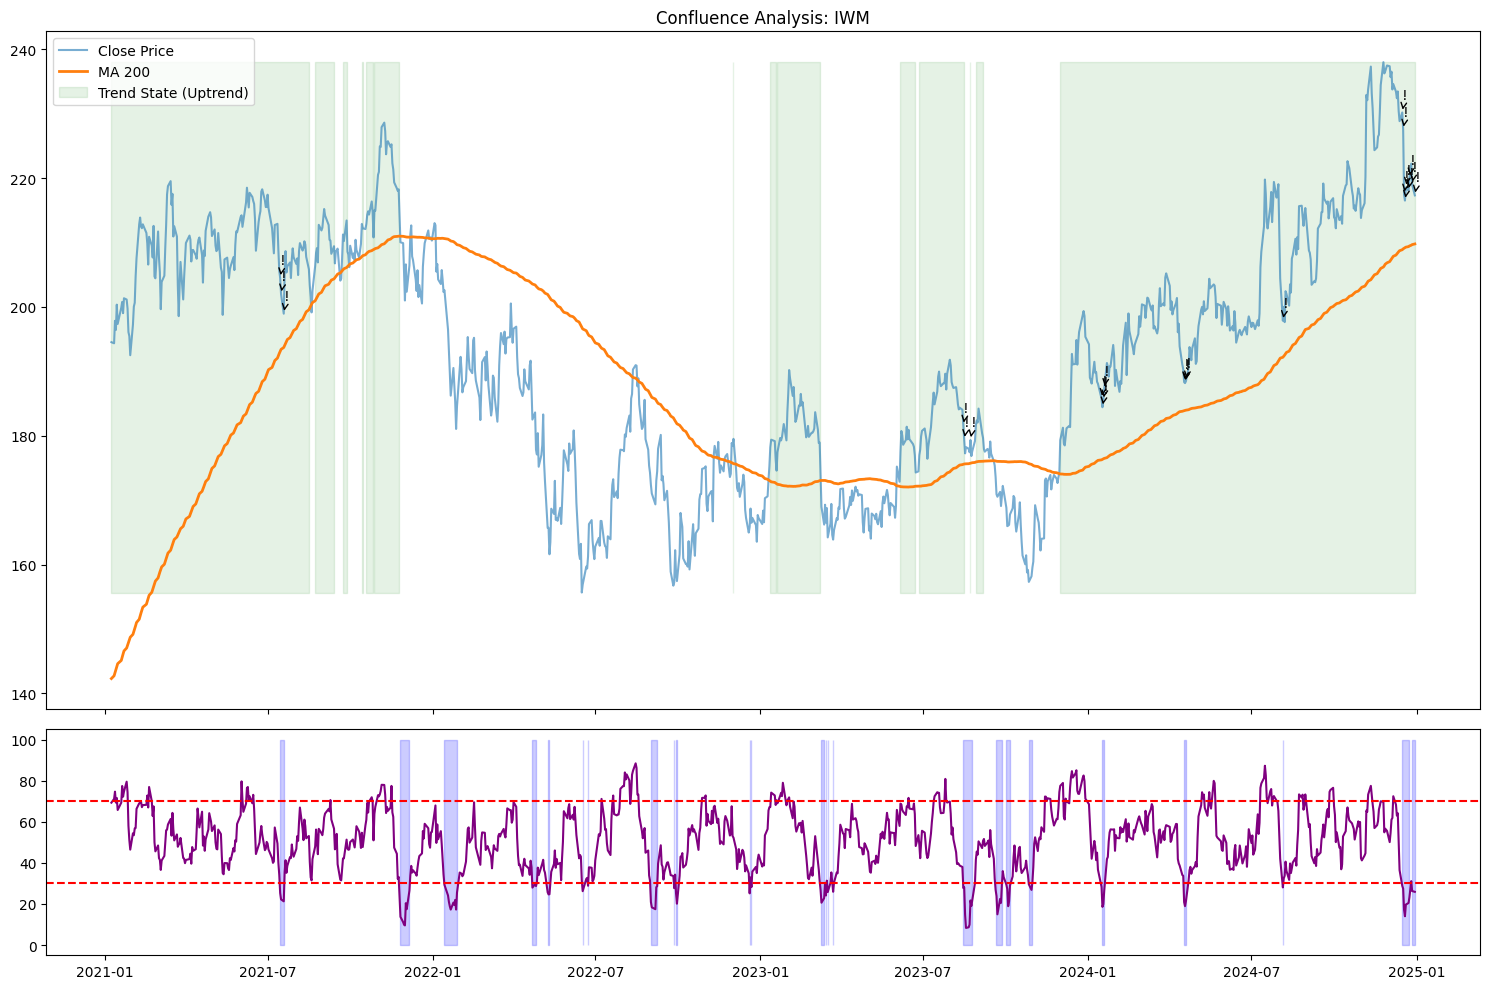

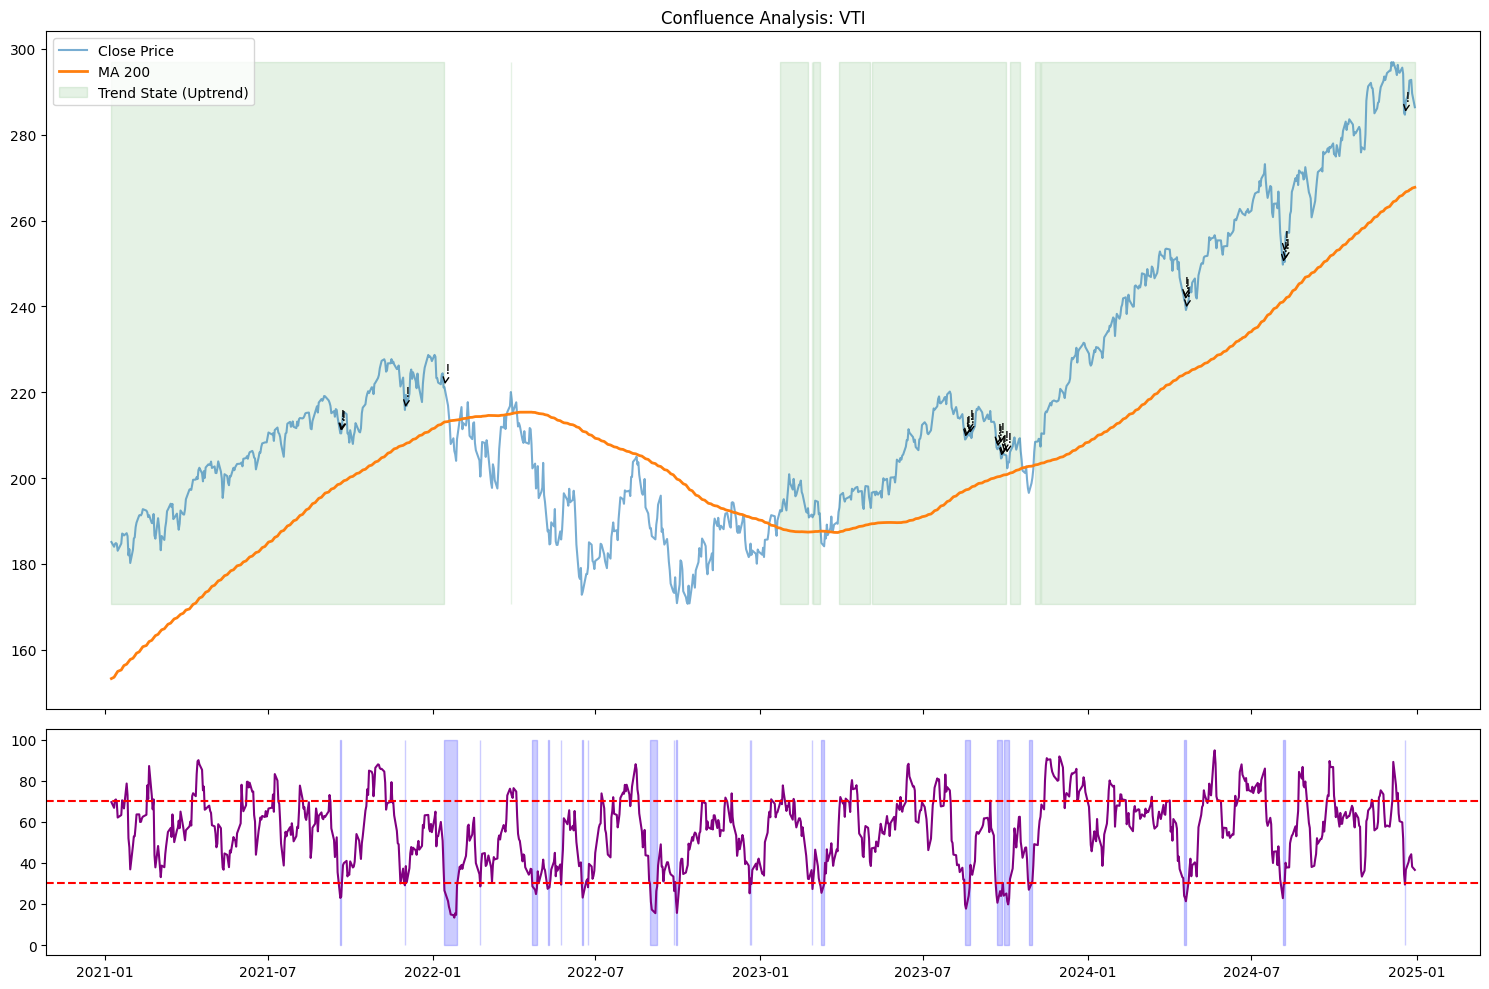

In [27]:
import matplotlib.pyplot as plt

def visualize_confluence_logic(df, ticker_name, window_ma=200, rsi_os=30, rsi_ob=70, epsilon=0.02):
    # Ensure we work on a copy and calculate indicators locally for this visualization
    temp_df = df.copy()
    ma_col = f'MA_{window_ma}'
    temp_df[ma_col] = temp_df['Close'].rolling(window=window_ma).mean()
    temp_df = calculate_rsi(temp_df)

    uptrend = temp_df['Close'] > (temp_df[ma_col] * (1 + epsilon))
    oversold = temp_df['RSI'] < rsi_os
    confluence = uptrend & oversold

    # Plotting the last 1000 days for clarity
    plot_df = temp_df.tail(1000)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(plot_df.index, plot_df['Close'], label='Close Price', alpha=0.6)
    ax1.plot(plot_df.index, plot_df[ma_col], label=f'MA {window_ma}', linewidth=2)
    ax1.fill_between(plot_df.index, plot_df['Close'].min(), plot_df['Close'].max(),
                     where=uptrend.tail(1000), color='green', alpha=0.1, label='Trend State (Uptrend)')

    ax2.plot(plot_df.index, plot_df['RSI'], color='purple', label='RSI')
    ax2.axhline(rsi_os, color='red', linestyle='--')
    ax2.axhline(rsi_ob, color='red', linestyle='--')
    ax2.fill_between(plot_df.index, 0, 100,
                     where=oversold.tail(1000), color='blue', alpha=0.2, label='RSI State (Oversold)')

    trade_dates = plot_df.index[confluence.tail(1000)]
    for date in trade_dates:
        ax1.annotate('!', xy=(date, plot_df.loc[date, 'Close']), xytext=(0, 10),
                     textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))

    ax1.set_title(f'Confluence Analysis: {ticker_name}')
    ax1.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

# Loop through all tickers to compare performance deep-dive using the existing function
for ticker in TARGET_TICKERS:
    visualize_confluence_logic(data_dict[ticker], ticker)

### **Portfolio Equity Curve: Persistent Confluence vs. Benchmarks**
This visualization compares the cumulative growth of a portfolio (equally weighted across SPY, QQQ, DIA, IWM, VTI) using the **Persistent Confluence** strategy against the **Buy & Hold** index and the standard **200-Day MA** crossover.

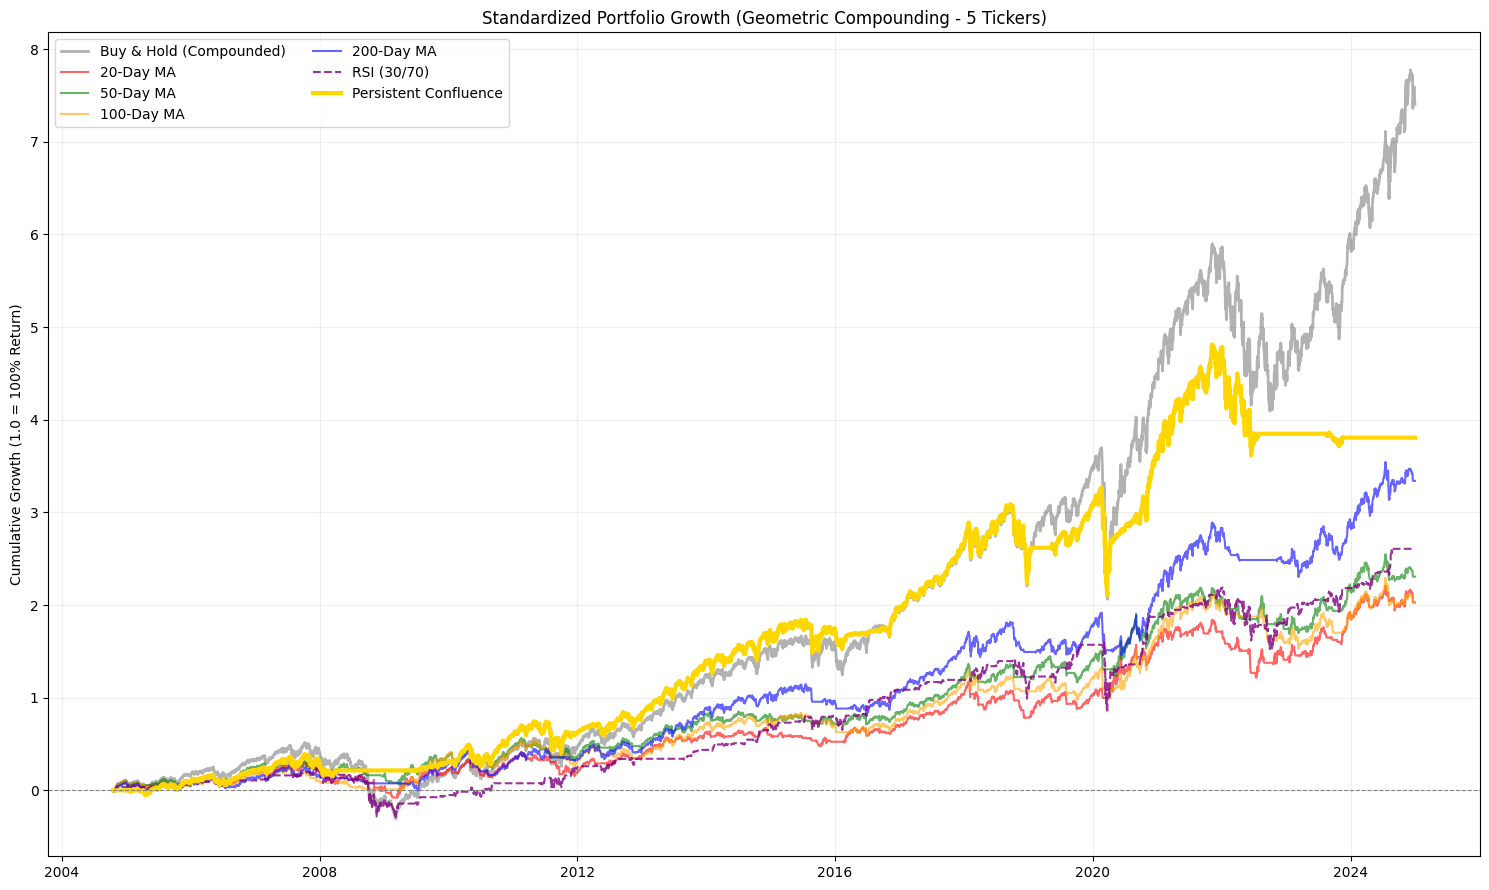

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Standardized Calculation Logic (Compounding) ---
portfolio_equity = {}
warm_up = 200

# 1. Buy & Hold Benchmark
bh_list = []
for t in TARGET_TICKERS:
    # Using fractional returns to compound
    daily_rets = data_dict[t]['Close'].pct_change().iloc[warm_up:]
    bh_list.append(daily_rets)

# Average daily returns across portfolio then compound
avg_bh_daily = pd.concat(bh_list, axis=1).mean(axis=1)
portfolio_equity['Buy & Hold'] = (1 + avg_bh_daily).cumprod() - 1

# 2. Moving Average Strategies (Compounded Daily)
for window in MA_WINDOWS.keys():
    ma_daily_list = []
    for t in TARGET_TICKERS:
        tr = trade_ma_with_fixed_trailing_stop(data_dict[t], window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        daily_rets = get_daily_strategy_returns(data_dict[t], tr).iloc[warm_up:]
        ma_daily_list.append(daily_rets)

    avg_ma_daily = pd.concat(ma_daily_list, axis=1).mean(axis=1)
    portfolio_equity[f'{window}-Day MA'] = (1 + avg_ma_daily).cumprod() - 1

# 3. Tactical RSI (30/70)
rsi_daily_list = []
for t in TARGET_TICKERS:
    tr = add_rsi_signals(data_dict[t], oversold=RSI_OVERSOLD, overbought=RSI_OVERBOUGHT)
    daily_rets = get_daily_strategy_returns(data_dict[t], tr).iloc[warm_up:]
    rsi_daily_list.append(daily_rets)

avg_rsi_daily = pd.concat(rsi_daily_list, axis=1).mean(axis=1)
portfolio_equity['RSI (30/70)'] = (1 + avg_rsi_daily).cumprod() - 1

# 4. Persistent Confluence
pst_daily_list = []
for t in TARGET_TICKERS:
    tr = trade_confluence_persistent_state(data_dict[t], window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)
    daily_rets = get_daily_strategy_returns(data_dict[t], tr).iloc[warm_up:]
    pst_daily_list.append(daily_rets)

avg_pst_daily = pd.concat(pst_daily_list, axis=1).mean(axis=1)
portfolio_equity['Persistent Confluence'] = (1 + avg_pst_daily).cumprod() - 1

# --- Plotting ---
plt.figure(figsize=(15, 9))

# Plot Benchmark
plt.plot(portfolio_equity['Buy & Hold'], label='Buy & Hold (Compounded)', color='black', linewidth=2, alpha=0.3)

# Plot MAs using their defined global colors
for window, color in MA_WINDOWS.items():
    plt.plot(portfolio_equity[f'{window}-Day MA'], label=f'{window}-Day MA', color=color, alpha=0.6)

# Plot Specialists
plt.plot(portfolio_equity['RSI (30/70)'], label='RSI (30/70)', color='purple', linestyle='--', alpha=0.8)
plt.plot(portfolio_equity['Persistent Confluence'], label='Persistent Confluence', color='gold', linewidth=3)

plt.title('Standardized Portfolio Growth (Geometric Compounding - 5 Tickers)')
plt.ylabel('Cumulative Growth (1.0 = 100% Return)')
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()